# 04 — Validering

Dette notebooket oppsummerer modellresultatene fra notebook `03a`, `03b` og `03c`,
og gjennomfører en strukturert validering av modellene.

**Valideringsopplegg**
- Felles out-of-sample sammenligning på testperioden 2024--2026
- Metrikker: MAE, RMSE og $R^2$
- Sammenligning mot enkle baselines (`Lag1`, `Lag24`)
- Koeffisientstabilitet og kryssmodell-sjekk for $\hat{\beta}_1$ (`cons_NO4`)
- Segmentert validering per år og sesong
- Ekstra kontroll av skjevhet og ytelse i høye pristimer
- Modellspesifikk validering:
  - `OLS`: residualdiagnostikk og økonometriske tester
  - `XGBoost`: prediktiv stabilitet, bias og feil ved høye priser
  - `MSDR`: prediktiv stabilitet, bias og feil ved høye priser

**Input:** `intermediate/df_iso.parquet`, `intermediate/preds_ols.parquet`, `intermediate/preds_xgb.parquet`, `intermediate/preds_msdr.parquet`, `intermediate/models_*.pkl`

**Output:** `intermediate/predictions.parquet`, `intermediate/validation_metrics_total.parquet`, `intermediate/validation_metrics_year.parquet`, `intermediate/validation_metrics_season.parquet`, `intermediate/validation_bias.parquet`, `intermediate/validation_tail.parquet`, `intermediate/validation_price_levels.parquet`, `intermediate/validation_coefficient_stability.parquet`


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import acf as compute_acf

from src.config import (
    INTERMEDIATE_DIR, FIG_DIR, TARGET, OLS_FEATURES,
    TRAIN_YEARS, TEST_YEARS, MODEL_COLS, MODEL_LABELS,
    apply_style, C1, C2, C3, C4, C5,
)
from src.model_training import split_features_target
from src.validation import (
    load_prediction_tables, build_validation_table, metrics_table,
    segmented_metrics, add_residual_columns, rolling_mae,
    bias_table, tail_metrics_table, price_level_table,
)

apply_style()
SEC07_DIR = f"{FIG_DIR}04/"
os.makedirs(SEC07_DIR, exist_ok=True)


In [2]:
df_iso = pd.read_parquet(f"{INTERMEDIATE_DIR}df_iso.parquet")
pred_tables = load_prediction_tables(INTERMEDIATE_DIR)
df_preds = build_validation_table(df_iso, pred_tables, target=TARGET, test_years=TEST_YEARS)
df_preds = add_residual_columns(df_preds, model_cols=MODEL_COLS)

print(f"ISO-timer totalt: {len(df_iso):,}")
print(f"Testtimer brukt i validering: {len(df_preds):,}")
print(f"Testår: {TEST_YEARS}")
display(df_preds.head())


ISO-timer totalt: 34,916
Testtimer brukt i validering: 9,844
Testår: [2024, 2025, 2026]


,actual,season,year,month,hour,TSLS,OLS,XGB,MSDR,Q50,...,Lag1,Lag24,resid_TSLS,resid_OLS,resid_XGB,resid_MSDR,resid_Q50,resid_Q90,resid_Lag1,resid_Lag24
Delivery Start (CET),,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,331.57,Winter,2024,1,0,482.107235,456.914711,154.220139,338.785612,498.882773,...,301.40,500.13,-150.537235,-125.344711,177.349861,-7.215612,-167.312773,-295.042864,30.17,-168.56
2024-01-01 01:00:00,319.23,Winter,2024,1,1,490.827112,460.079222,165.302444,287.979470,502.871952,...,331.57,500.13,-171.597112,-140.849222,153.927556,31.250530,-183.641952,-310.865889,-12.34,-180.90
2024-01-01 02:00:00,299.04,Winter,2024,1,2,427.377424,423.045775,135.569016,261.687820,490.533396,...,319.23,486.30,-128.337424,-124.005775,163.470984,37.352180,-191.493396,-296.111267,-20.19,-187.26
2024-01-01 04:00:00,269.32,Winter,2024,1,4,403.252089,404.276952,97.697021,258.692663,485.180614,...,299.04,445.20,-133.932089,-134.956952,171.622979,10.627337,-215.860614,-303.751219,-29.72,-175.88
2024-01-01 06:00:00,253.72,Winter,2024,1,6,434.896497,430.996230,159.382355,271.934572,497.763086,...,269.32,424.00,-181.176497,-177.276230,94.337645,-18.214572,-244.043086,-348.562936,-15.60,-170.28


## 4.1 Felles oppsummering av modellresultater

Denne delen sammenligner alle modellene på samme testperiode. Målet er å etablere et felles utgangspunkt før modellspesifikk validering.


In [3]:
metrics_total = metrics_table(df_preds, model_cols=MODEL_COLS, model_labels=MODEL_LABELS)
metrics_year = segmented_metrics(df_preds, "year", model_cols=MODEL_COLS, model_labels=MODEL_LABELS)
metrics_season = segmented_metrics(df_preds, "season", model_cols=MODEL_COLS, model_labels=MODEL_LABELS)
bias_total = bias_table(df_preds, model_cols=MODEL_COLS, model_labels=MODEL_LABELS)
tail_total, tail_cutoff = tail_metrics_table(df_preds, quantile=0.90, model_cols=MODEL_COLS, model_labels=MODEL_LABELS)
price_level_metrics, q_low, q_high = price_level_table(df_preds, model_cols=MODEL_COLS, model_labels=MODEL_LABELS)

print("Samlet valideringsoppsummering (testperiode):")
display(metrics_total)

print("Gjennomsnittlig skjevhet og medianfeil:")
display(bias_total)

print(f"Ytelse i høye pristimer (øverste 10 %, cutoff = {tail_cutoff:.1f} NOK/MWh):")
display(tail_total)


Samlet valideringsoppsummering (testperiode):


,Modell,MAE,RMSE,R²,N
0,Baseline lag-1,26.7,77.5,0.9083,9844
1,Baseline lag-24,93.2,197.0,0.4075,9844
2,MS-DR (2 reg.),118.3,183.6,0.4856,9844
3,QuantReg Q50,125.4,207.5,0.3429,9844
4,OLS (HAC),154.6,222.8,0.2425,9844
5,XGBoost,180.7,264.5,-0.0679,9844
6,2SLS (HAC),188.6,251.6,0.0340,9844
7,QuantReg Q90,293.0,360.5,-0.9837,9844


Gjennomsnittlig skjevhet og medianfeil:


,Modell,ME,Medianfeil,MAPE
0,2SLS (HAC),93.00,104.74,399.13
1,OLS (HAC),53.76,68.09,304.92
2,XGBoost,-3.08,32.07,314.26
3,MS-DR (2 reg.),68.16,58.35,300.49
4,QuantReg Q50,4.06,35.49,239.84
5,QuantReg Q90,249.88,233.26,742.06
6,Baseline lag-1,-0.06,0.05,29.47
7,Baseline lag-24,-0.71,0.00,123.86


Ytelse i høye pristimer (øverste 10 %, cutoff = 519.8 NOK/MWh):


,Modell,MAE,RMSE,R²,N
0,Baseline lag-1,107.0,199.7,0.5719,985
1,MS-DR (2 reg.),231.2,347.5,-0.2959,985
2,QuantReg Q90,250.4,371.6,-0.4824,985
3,Baseline lag-24,308.6,434.0,-1.0221,985
4,2SLS (HAC),327.2,435.1,-1.0317,985
5,OLS (HAC),357.0,478.3,-1.4558,985
6,QuantReg Q50,405.2,543.6,-2.1714,985
7,XGBoost,462.9,544.1,-2.1783,985


In [4]:
print("Metrikker per år (MAE):")
display(metrics_year.pivot(index="Modell", columns="Segment", values="MAE").round(1))

print("Metrikker per sesong (MAE):")
display(metrics_season.pivot(index="Modell", columns="Segment", values="MAE").round(1))

print(f"Prisnivåer: lav <= {q_low:.1f}, normal <= {q_high:.1f}, høy > {q_high:.1f} NOK/MWh")
display(price_level_metrics.pivot(index="Modell", columns="Prisnivå", values="MAE").round(1))


Metrikker per år (MAE):


Segment,2024,2025,2026
Modell,,,
2SLS (HAC),186.4,179.4,307.1
Baseline lag-1,21.4,22.8,112.6
Baseline lag-24,89.2,76.6,306.1
MS-DR (2 reg.),127.3,99.7,247.3
OLS (HAC),165.9,130.6,322.8
QuantReg Q50,132.3,98.4,362.1
QuantReg Q90,300.8,289.6,266.9
XGBoost,246.0,109.0,421.0


Metrikker per sesong (MAE):


Segment,Autumn,Spring,Summer,Winter
Modell,,,,
2SLS (HAC),201.4,186.5,87.1,247.2
Baseline lag-1,20.4,30.1,13.4,37.1
Baseline lag-24,90.2,88.9,43.4,130.5
MS-DR (2 reg.),113.5,111.1,43.3,175.6
OLS (HAC),180.6,131.3,64.4,212.4
QuantReg Q50,122.0,115.4,47.7,185.3
QuantReg Q90,388.5,193.7,196.0,363.6
XGBoost,166.9,197.6,90.0,236.3


Prisnivåer: lav <= 50.6, normal <= 287.2, høy > 287.2 NOK/MWh


Prisnivå,Høy pris,Lav pris,Normal pris
Modell,,,
2SLS (HAC),181.0,149.8,235.1
Baseline lag-1,53.8,8.3,18.0
Baseline lag-24,174.4,33.1,71.9
MS-DR (2 reg.),168.0,94.9,92.1
OLS (HAC),170.1,104.7,188.9
QuantReg Q50,182.1,77.6,116.4
QuantReg Q90,202.7,262.0,414.5
XGBoost,276.3,96.9,168.7


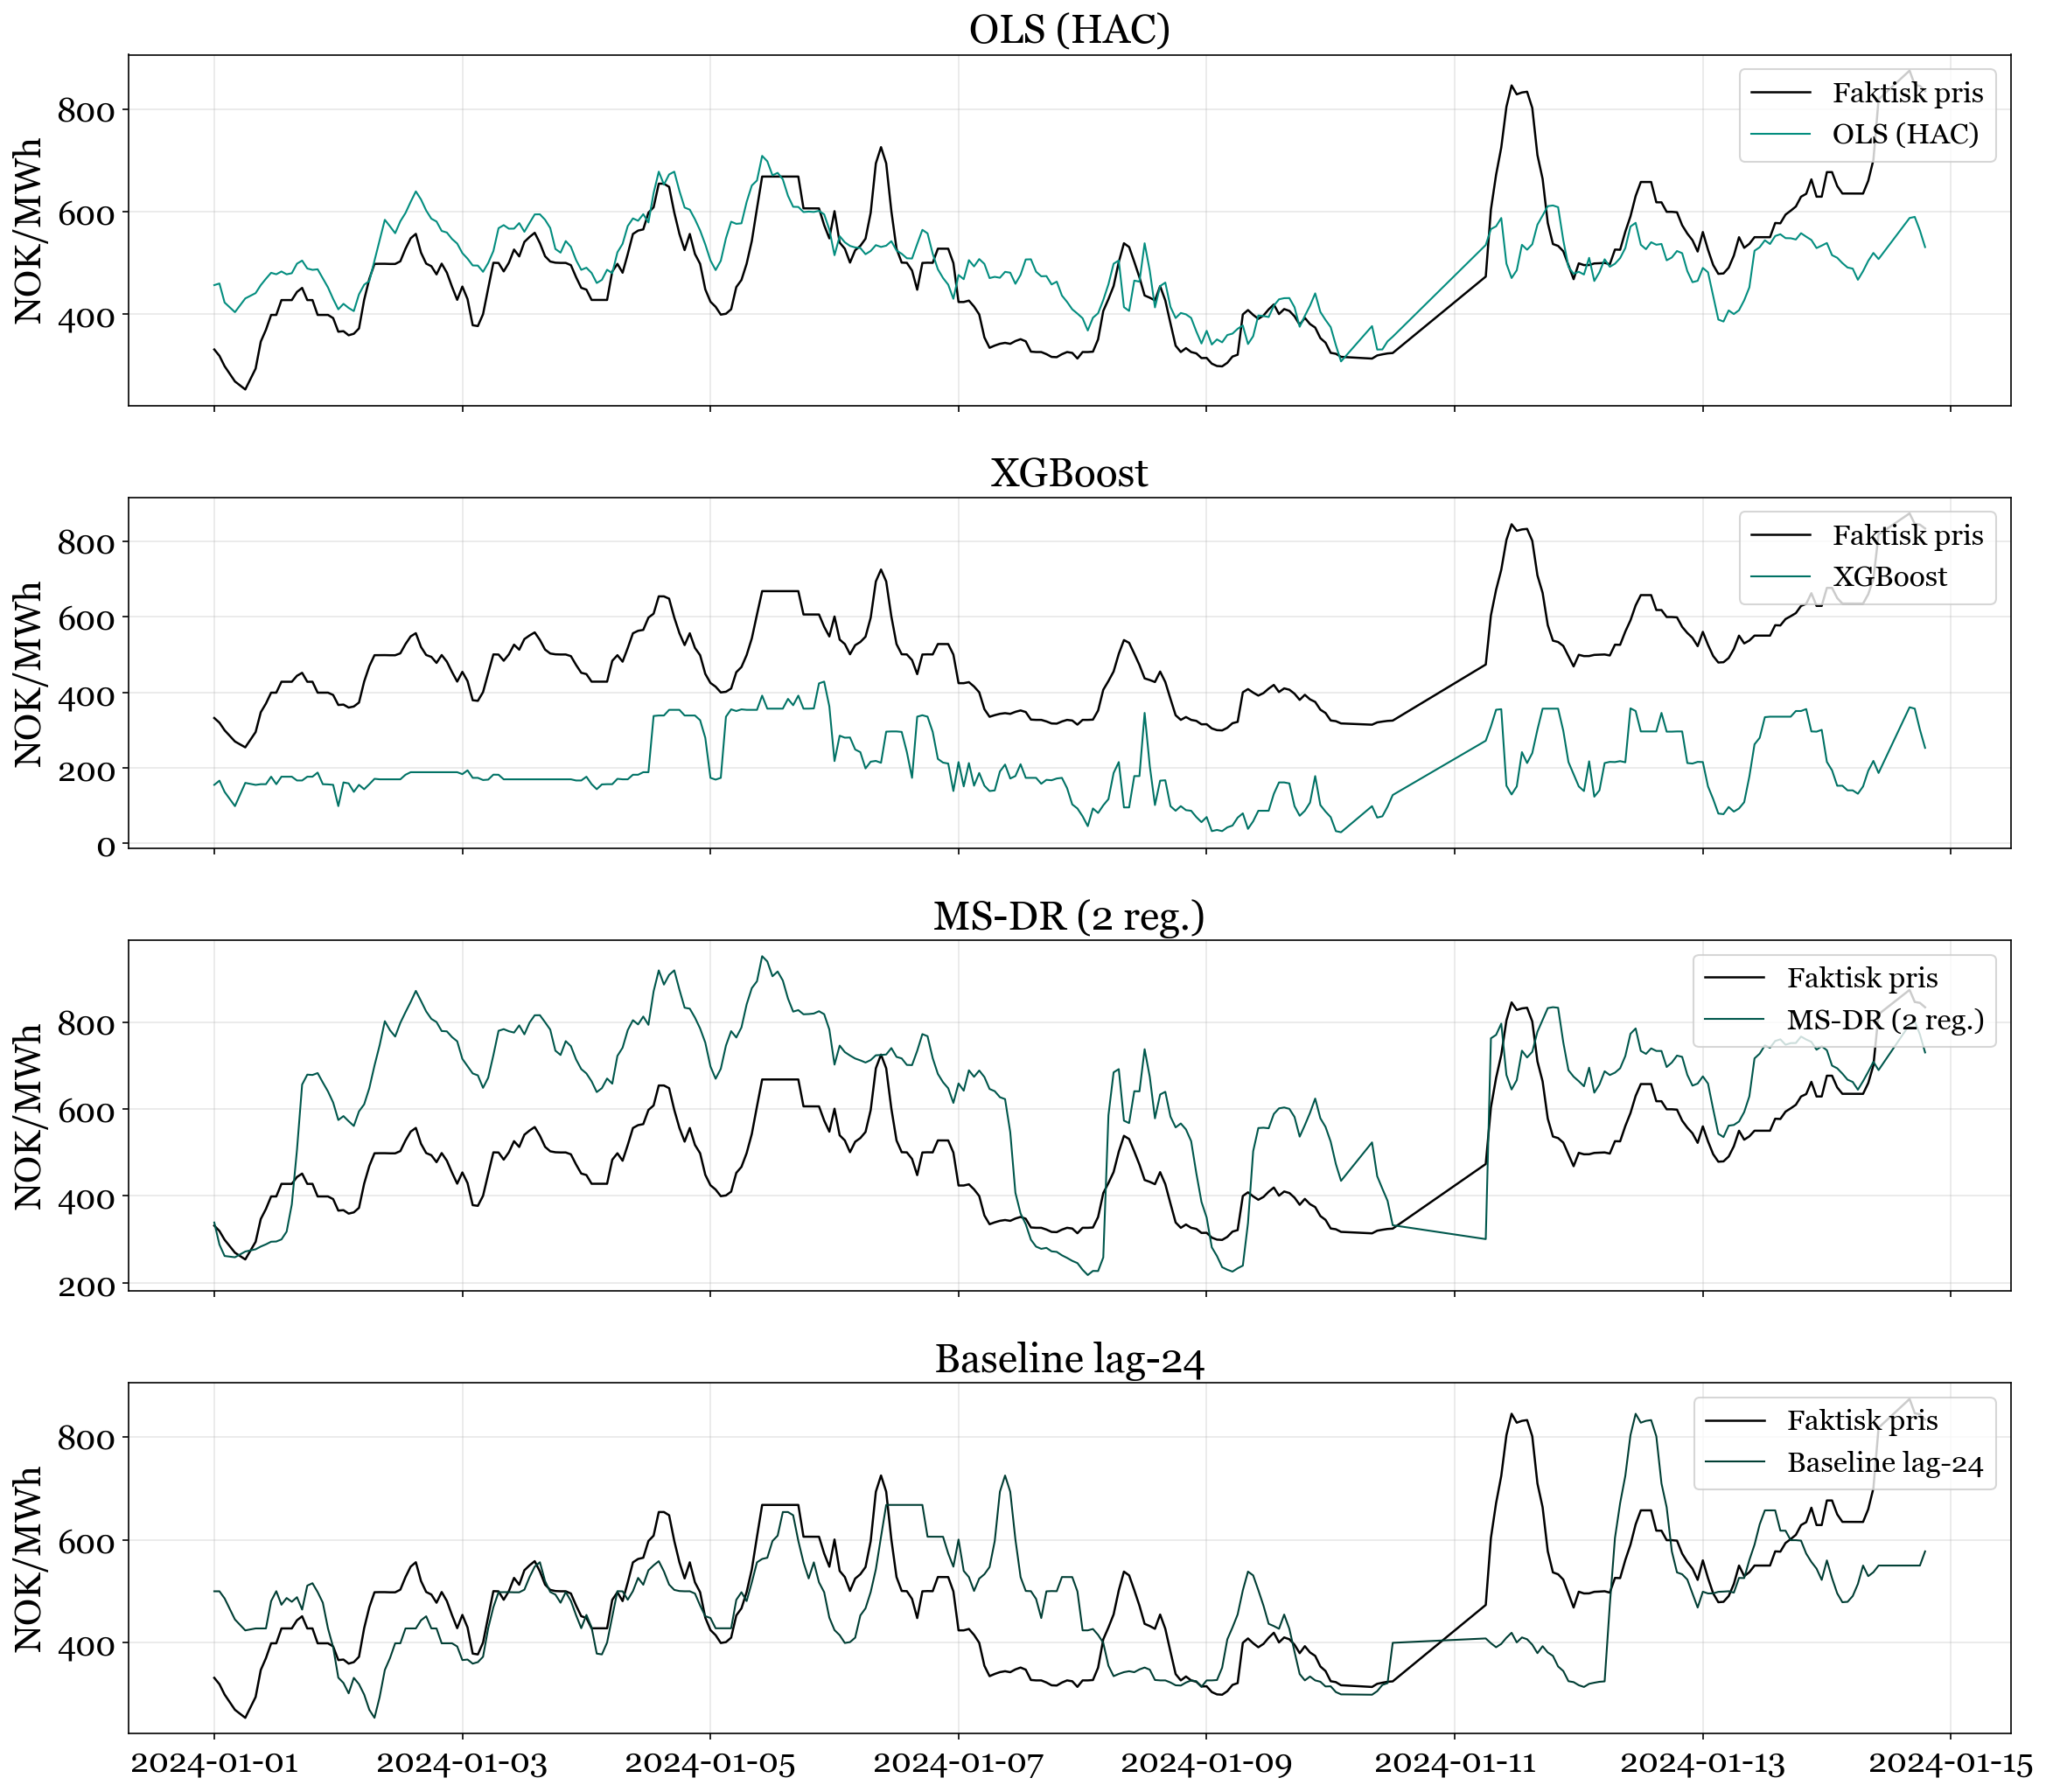

In [5]:
window = df_preds.loc["2024-01-01":"2024-01-14"]
fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)
for ax, model, color in zip(axes, ["OLS", "XGB", "MSDR", "Lag24"], [C1, C2, C3, C4]):
    ax.plot(window.index, window["actual"], color="black", lw=1.2, label="Faktisk pris")
    ax.plot(window.index, window[model], color=color, lw=1.0, label=MODEL_LABELS[model])
    ax.set_ylabel("NOK/MWh")
    ax.set_title(MODEL_LABELS[model])
    ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(f"{SEC07_DIR}validation_overview_timeseries.pdf", bbox_inches="tight")
plt.show()


/var/folders/qm/yxw8ymd954bbr1l26gjszr0r0000gn/T/ipykernel_53713/1901347379.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(resid_data, labels=[MODEL_LABELS[m] for m in MODEL_COLS], showfliers=False)


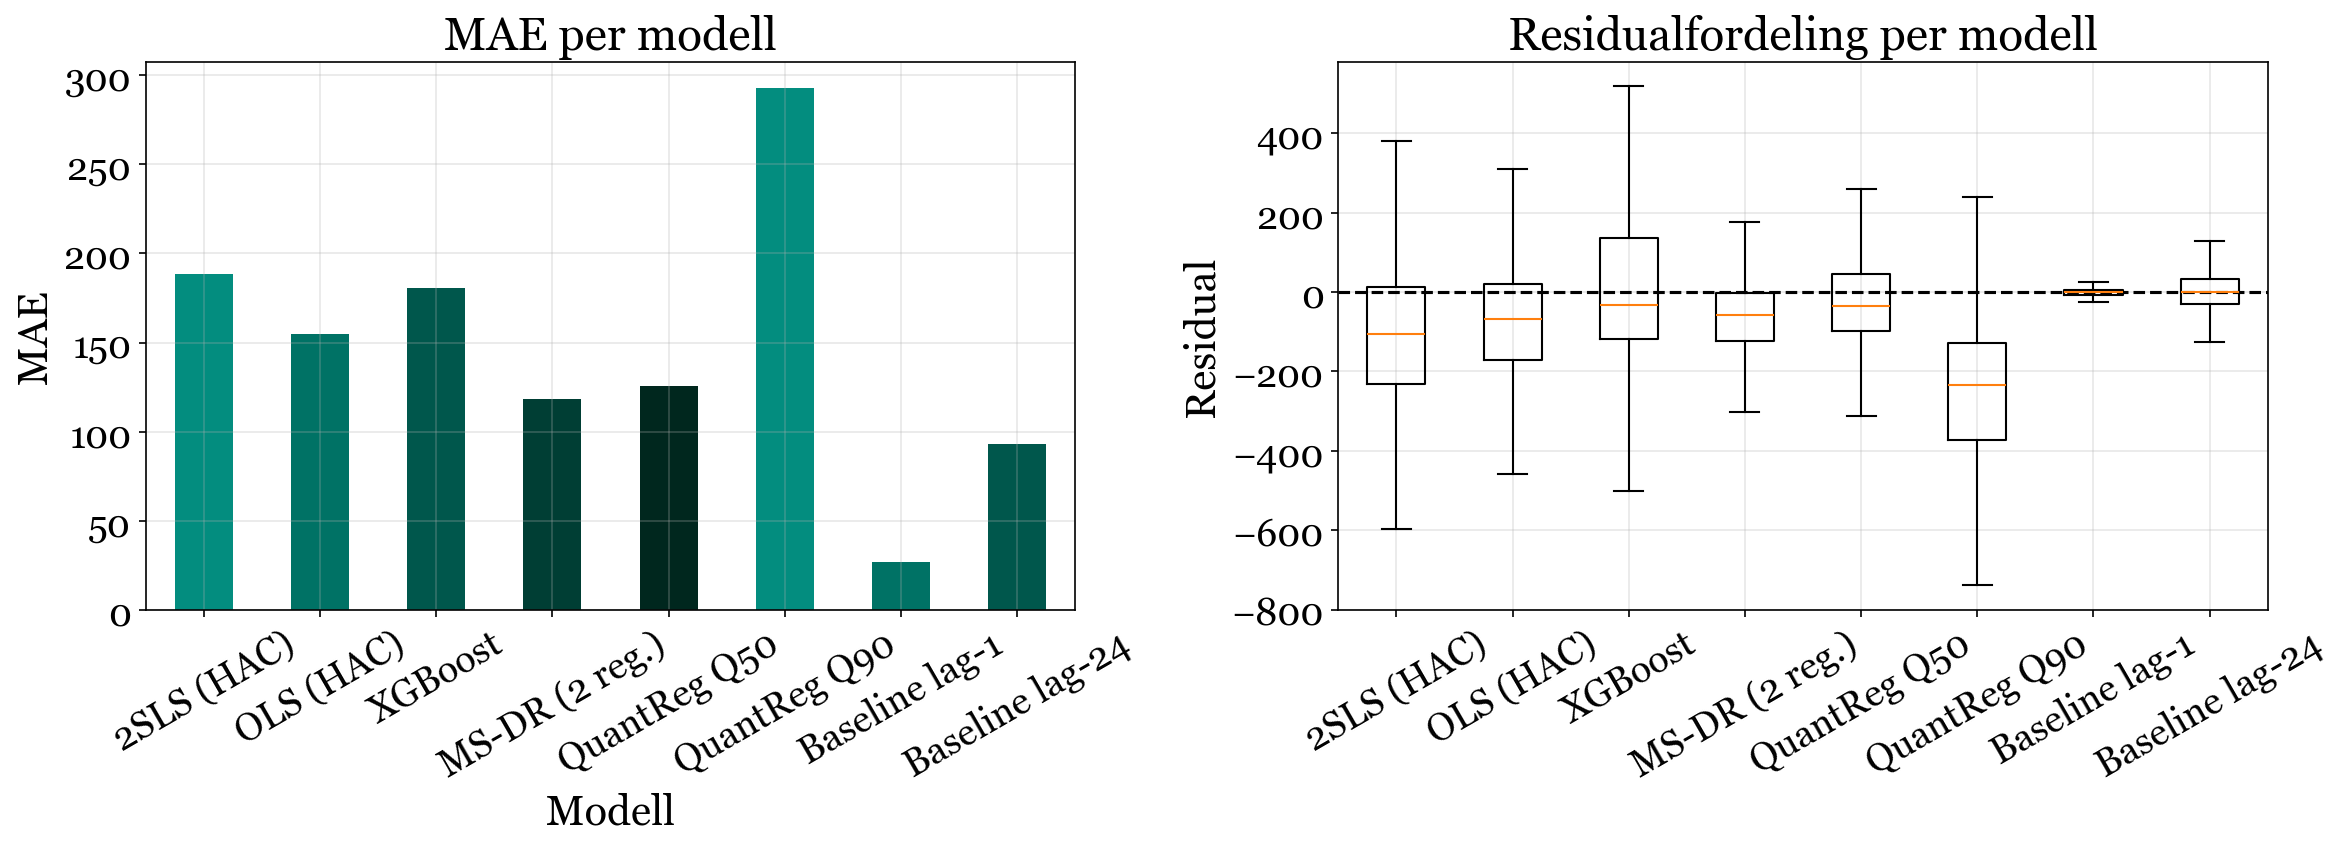

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
mae_plot = metrics_total.set_index("Modell").loc[[MODEL_LABELS[m] for m in MODEL_COLS], "MAE"]
mae_plot.plot(kind="bar", ax=axes[0], color=[C1, C2, C3, C4, C5])
axes[0].set_title("MAE per modell")
axes[0].set_ylabel("MAE")
axes[0].tick_params(axis="x", rotation=30)

resid_data = [df_preds[f"resid_{m}"].dropna() for m in MODEL_COLS]
axes[1].boxplot(resid_data, labels=[MODEL_LABELS[m] for m in MODEL_COLS], showfliers=False)
axes[1].axhline(0, color="black", ls="--")
axes[1].set_title("Residualfordeling per modell")
axes[1].set_ylabel("Residual")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(f"{SEC07_DIR}validation_overview_metrics.pdf", bbox_inches="tight")
plt.show()


## 4.2 Koeffisientstabilitet og kryssmodell-sjekk

Hovedmålet med modellene er ikke prediksjon, men estimering av $\beta_1$ (koeffisienten på `cons_NO4`), som kvantifiserer marginal priseffekt av økt forbruk. For å vurdere om hovedfunnet er robust mot valg av spesifikasjon, sammenlignes $\hat{\beta}_1$ med 95 % konfidensintervall på tvers av OLS, 2SLS, MS-DR (per regime og ergodisk vektet) og kvantilregresjon (Q50 og Q90). XGBoost utelates fordi modellen ikke produserer en direkte tolkbar koeffisient.

Implisert priseffekt av Stargate (230 MW) rapporteres i siste kolonne som $\hat{\beta}_1 \cdot 230$. Dette er en ren skalar oversettelse av koeffisienten, og må ikke forveksles med den fulle simuleringen i kapittel 5 — den endelige effekten avhenger også av regimeskift-komponenten.


In [7]:
import pickle
from src.config import STARGATE_MW

def _load_payload(name):
    with open(f"{INTERMEDIATE_DIR}models_{name}.pkl", "rb") as f:
        return pickle.load(f)

ols_payload  = _load_payload("ols")
tsls_payload = _load_payload("tsls")
msdr_payload = _load_payload("msdr")
qr_payload   = _load_payload("quantreg")

rows = []

# OLS (HAC)
ols_est = ols_payload["estimator"]
b = float(ols_est.params["cons_NO4"]); se = float(ols_est.bse["cons_NO4"])
rows.append({"Modell": "OLS (HAC)", "beta": b, "SE": se, "ci_l": b - 1.96*se, "ci_u": b + 1.96*se})

# 2SLS (HAC)
tsls_est = tsls_payload["estimator"]
b = float(tsls_est.params["cons_NO4"]); se = float(tsls_est.std_errors["cons_NO4"])
rows.append({"Modell": "2SLS (HAC)", "beta": b, "SE": se, "ci_l": b - 1.96*se, "ci_u": b + 1.96*se})

# MS-DR — per regime + ergodisk vektet
msdr_est = msdr_payload["estimator"]
ergodic = np.asarray(msdr_payload["ergodic_probs"]).flatten()
params = msdr_est.params
bse = msdr_est.bse
names = list(params.index)
candidates = [("cons_NO4[0]", "cons_NO4[1]"), ("x1[0]", "x1[1]")]
for n0, n1 in candidates:
    if n0 in names and n1 in names:
        b0, b1 = float(params[n0]), float(params[n1])
        s0, s1 = float(bse[n0]), float(bse[n1])
        break
else:
    raise KeyError(f"Fant ikke cons_NO4-koeffisient i MS-DR. Tilgjengelige: {names}")
rows.append({"Modell": "MS-DR Regime 0", "beta": b0, "SE": s0, "ci_l": b0 - 1.96*s0, "ci_u": b0 + 1.96*s0})
rows.append({"Modell": "MS-DR Regime 1", "beta": b1, "SE": s1, "ci_l": b1 - 1.96*s1, "ci_u": b1 + 1.96*s1})
p0, p1 = float(ergodic[0]), float(ergodic[1])
b_w = p0 * b0 + p1 * b1
se_w = np.sqrt((p0 * s0) ** 2 + (p1 * s1) ** 2)
rows.append({"Modell": f"MS-DR (ergodisk vektet, π=[{p0:.2f}, {p1:.2f}])", "beta": b_w, "SE": se_w, "ci_l": b_w - 1.96*se_w, "ci_u": b_w + 1.96*se_w})

# Kvantilregresjon Q50 og Q90
qr_est = qr_payload["estimators"]
for q in [0.5, 0.9]:
    m = qr_est[q]
    b = float(m.params["cons_NO4"]); se = float(m.bse["cons_NO4"])
    rows.append({"Modell": f"QuantReg Q{int(q*100)}", "beta": b, "SE": se, "ci_l": b - 1.96*se, "ci_u": b + 1.96*se})

coef_stability = pd.DataFrame(rows)
coef_stability[f"Effekt {STARGATE_MW} MW (NOK/MWh)"] = (coef_stability["beta"] * STARGATE_MW).round(1)

display_cols = pd.DataFrame({
    "Modell":                       coef_stability["Modell"],
    "β̂₁ (NOK/MWh per MW)":         coef_stability["beta"].round(4),
    "SE":                           coef_stability["SE"].round(4),
    "95 % KI":                      coef_stability.apply(lambda r: f"[{r.ci_l:.3f}, {r.ci_u:.3f}]", axis=1),
    f"Effekt {STARGATE_MW} MW":     coef_stability[f"Effekt {STARGATE_MW} MW (NOK/MWh)"],
})

print("Koeffisientstabilitet for forbruk (cons_NO4) på tvers av modeller:")
display(display_cols)

coef_stability.to_parquet(f"{INTERMEDIATE_DIR}validation_coefficient_stability.parquet")
print(f"\nLagret {INTERMEDIATE_DIR}validation_coefficient_stability.parquet")


Koeffisientstabilitet for forbruk (cons_NO4) på tvers av modeller:


,Modell,β̂₁ (NOK/MWh per MW),SE,95 % KI,Effekt 230 MW
0,OLS (HAC),0.3034,0.0361,"[0.233, 0.374]",69.8
1,2SLS (HAC),0.6163,0.0823,"[0.455, 0.778]",141.7
2,MS-DR Regime 0,0.1470,0.0017,"[0.144, 0.150]",33.8
3,MS-DR Regime 1,0.3975,0.0075,"[0.383, 0.412]",91.4
4,"MS-DR (ergodisk vektet, π=[0.50, 0.50])",0.2723,0.0038,"[0.265, 0.280]",62.6
5,QuantReg Q50,0.1112,0.0049,"[0.102, 0.121]",25.6
6,QuantReg Q90,0.2214,0.0090,"[0.204, 0.239]",50.9



Lagret intermediate/validation_coefficient_stability.parquet


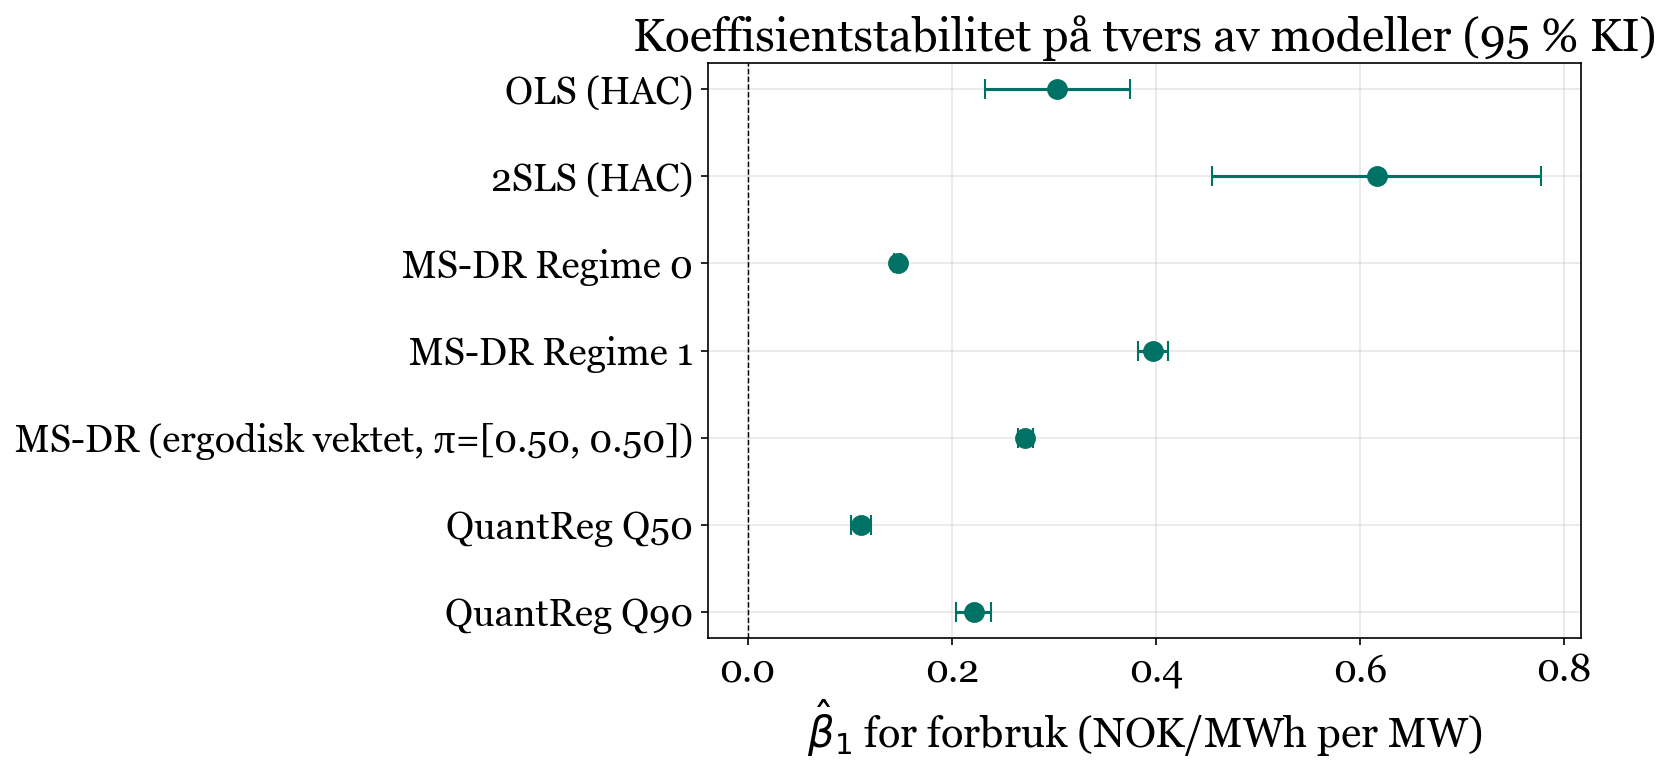

In [8]:
fig, ax = plt.subplots(figsize=(11, 5.5))
y = np.arange(len(coef_stability))[::-1]
ax.errorbar(
    coef_stability["beta"], y,
    xerr=[coef_stability["beta"] - coef_stability["ci_l"], coef_stability["ci_u"] - coef_stability["beta"]],
    fmt="o", capsize=5, color=C2, markersize=9, lw=1.5,
)
ax.set_yticks(y)
ax.set_yticklabels(coef_stability["Modell"])
ax.axvline(0, color="black", lw=0.7, ls="--")
ax.set_xlabel(r"$\hat{\beta}_1$ for forbruk (NOK/MWh per MW)")
ax.set_title("Koeffisientstabilitet på tvers av modeller (95 % KI)")
plt.tight_layout()
plt.savefig(f"{SEC07_DIR}coefficient_stability_forest.pdf", bbox_inches="tight")
plt.show()


## Koefisientstabilitet over tid

Forrige seksjon viser stabilitet *på tvers av modeller*. Her undersøkes stabilitet
*på tvers av tid* ved å reestimere OLS (HAC) og 2SLS (HAC) separat for hvert
kalenderår i både trenings- (2020–2023) og testperioden (2024–2025). 2026
utelates fordi det kun inneholder ~2 måneder med data. Hvis $\hat{\beta}_1$
varierer kraftig mellom år med svært ulike markedsforhold (lavprisåret 2020,
energikrisen 2022, normaliseringen 2023, og det avvikende 2024 med strammere
kraftbalanse), er det et tegn på at den estimerte sammenhengen mellom forbruk
og pris ikke er strukturelt stabil. Veileder ber spesielt om at avviket i 2024
dokumenteres tydelig.

In [9]:
from src.config import (
    OLS_FEATURES, IV_ENDOG, IV_INSTRUMENTS, IV_EXOG,
    TRAIN_YEARS, TEST_YEARS, STARGATE_MW,
)
from src.model_training import fit_2sls

# Inkluder testår 2024 og 2025 (2026 utelates pga. kun ~2 mnd data)
EVAL_YEARS = list(TRAIN_YEARS) + [y for y in TEST_YEARS if y < 2026]

def _periode(y):
    return "Trening" if y in TRAIN_YEARS else "Test"

rows = []
for year in EVAL_YEARS:
    df_year = df_iso[df_iso.index.year == year].copy()
    n = len(df_year)
    if n < 100:
        continue

    # Drop dummy-kolonner med zero-variance i dette årets utvalg
    feat_year = [c for c in OLS_FEATURES if df_year[c].nunique() > 1]
    exog_year = [c for c in IV_EXOG if df_year[c].nunique() > 1]

    # OLS (HAC, 24 lag)
    try:
        X = sm.add_constant(df_year[feat_year].astype(float), has_constant="add")
        y = df_year[TARGET].astype(float)
        ols_y = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 24})
        b, se = float(ols_y.params["cons_NO4"]), float(ols_y.bse["cons_NO4"])
        rows.append({"Periode": _periode(year), "År": year, "Modell": "OLS (HAC)", "N": n,
                     "beta": b, "SE": se, "ci_l": b - 1.96*se, "ci_u": b + 1.96*se})
    except Exception as e:
        print(f"OLS feilet for {year}: {e}")

    # 2SLS (HAC, 24 lag)
    try:
        tsls_y, _ = fit_2sls(
            df_year, y_col=TARGET, endog_col=IV_ENDOG,
            instrument_cols=IV_INSTRUMENTS, exog_cols=exog_year, hac_lags=24,
        )
        b = float(tsls_y.params["cons_NO4"])
        se = float(tsls_y.std_errors["cons_NO4"])
        rows.append({"Periode": _periode(year), "År": year, "Modell": "2SLS (HAC)", "N": n,
                     "beta": b, "SE": se, "ci_l": b - 1.96*se, "ci_u": b + 1.96*se})
    except Exception as e:
        print(f"2SLS feilet for {year}: {e}")

coef_year = pd.DataFrame(rows)

display_year = pd.DataFrame({
    "Periode":                  coef_year["Periode"],
    "År":                       coef_year["År"],
    "Modell":                   coef_year["Modell"],
    "N (timer)":                coef_year["N"],
    "β̂₁ (NOK/MWh per MW)":     coef_year["beta"].round(4),
    "SE":                       coef_year["SE"].round(4),
    "95 % KI":                  coef_year.apply(lambda r: f"[{r.ci_l:.3f}, {r.ci_u:.3f}]", axis=1),
    f"Effekt {STARGATE_MW} MW": (coef_year["beta"] * STARGATE_MW).round(1),
})

print("Per-år koeffisientestimater for cons_NO4 (trenings- og testperioden):")
display(display_year)

coef_year.to_parquet(f"{INTERMEDIATE_DIR}validation_coefficient_per_year.parquet")
print(f"\nLagret {INTERMEDIATE_DIR}validation_coefficient_per_year.parquet")


Per-år koeffisientestimater for cons_NO4 (trenings- og testperioden):


,Periode,År,Modell,N (timer),β̂₁ (NOK/MWh per MW),SE,95 % KI,Effekt 230 MW
0,Trening,2020,OLS (HAC),3503,0.0686,0.0158,"[0.038, 0.100]",15.8
1,Trening,2020,2SLS (HAC),3503,0.1078,0.0262,"[0.056, 0.159]",24.8
2,Trening,2021,OLS (HAC),7021,0.4027,0.0974,"[0.212, 0.594]",92.6
3,Trening,2021,2SLS (HAC),7021,0.5607,0.1492,"[0.268, 0.853]",129.0
4,Trening,2022,OLS (HAC),8118,0.3060,0.0846,"[0.140, 0.472]",70.4
5,Trening,2022,2SLS (HAC),8118,0.7172,0.1619,"[0.400, 1.034]",164.9
6,Trening,2023,OLS (HAC),6430,0.1790,0.0501,"[0.081, 0.277]",41.2
7,Trening,2023,2SLS (HAC),6430,0.4015,0.1204,"[0.166, 0.637]",92.3
8,Test,2024,OLS (HAC),4033,0.1330,0.0397,"[0.055, 0.211]",30.6
9,Test,2024,2SLS (HAC),4033,0.2656,0.0690,"[0.130, 0.401]",61.1



Lagret intermediate/validation_coefficient_per_year.parquet


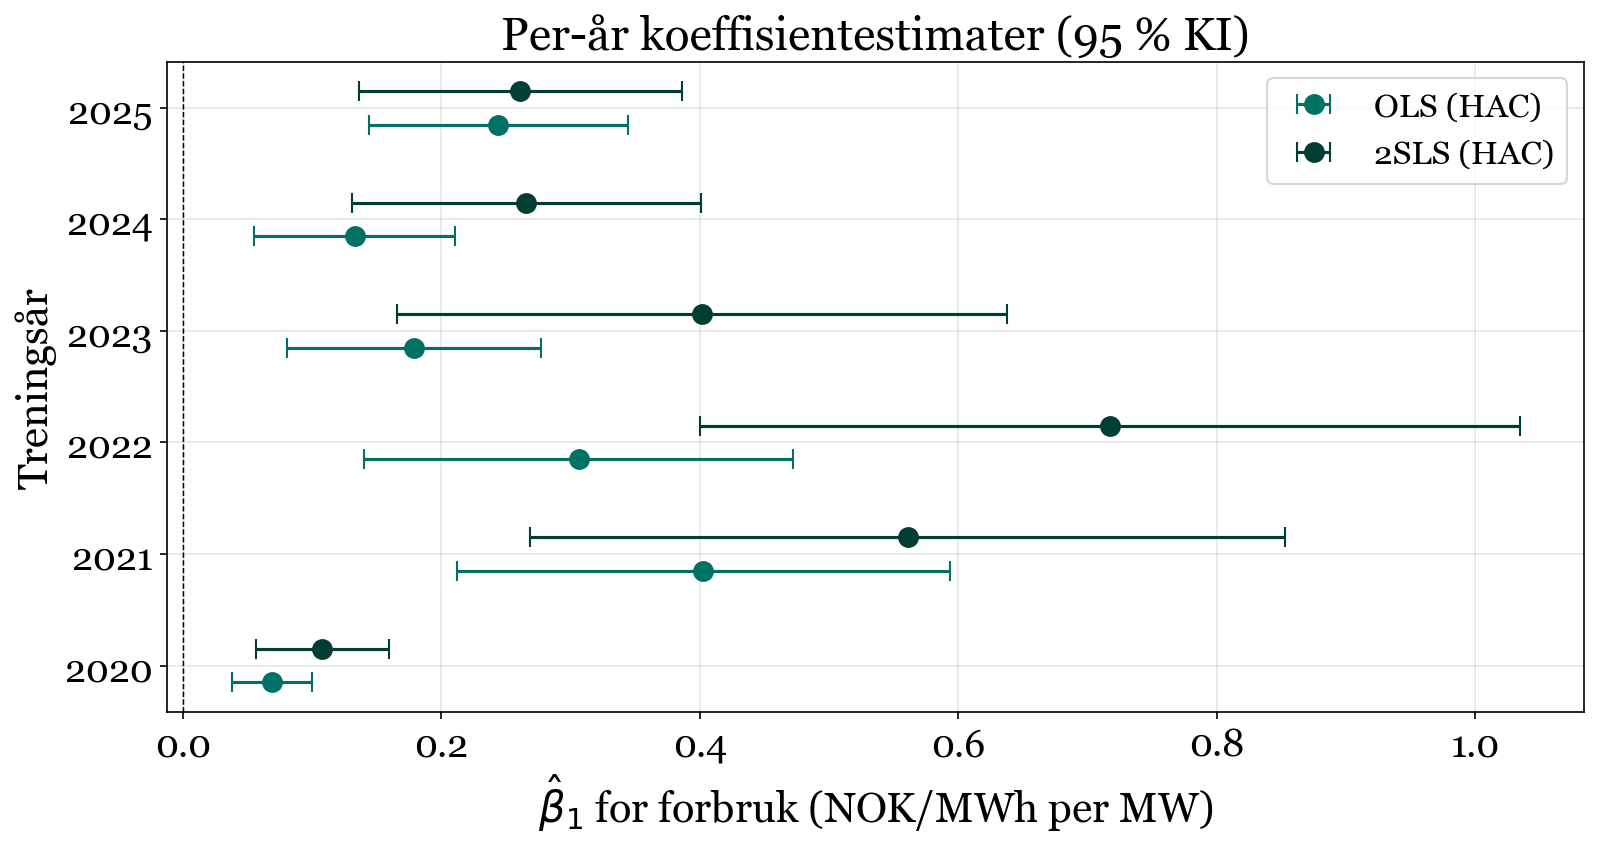

In [10]:
fig, ax = plt.subplots(figsize=(11, 6))
colors  = {"OLS (HAC)": C2, "2SLS (HAC)": C4}
offsets = {"OLS (HAC)": -0.15, "2SLS (HAC)": 0.15}

for model_name, color in colors.items():
    sub = coef_year[coef_year["Modell"] == model_name]
    if sub.empty:
        continue
    y_pos = sub["År"].values + offsets[model_name]
    ax.errorbar(
        sub["beta"], y_pos,
        xerr=[sub["beta"] - sub["ci_l"], sub["ci_u"] - sub["beta"]],
        fmt="o", capsize=5, color=color, markersize=9, lw=1.5, label=model_name,
    )

ax.set_yticks(sorted(coef_year["År"].unique()))
ax.axvline(0, color="black", lw=0.7, ls="--")
ax.set_xlabel(r"$\hat{\beta}_1$ for forbruk (NOK/MWh per MW)")
ax.set_ylabel("Treningsår")
ax.set_title("Per-år koeffisientestimater (95 % KI)")
ax.legend(loc="best")
plt.tight_layout()
plt.savefig(f"{SEC07_DIR}coefficient_per_year_forest.pdf", bbox_inches="tight")
plt.show()


### Koeffisientstabilitet over kvartalsvise CV-folds

Per-år-analysen over gir kun 6 folds, og ett kvartal med ekstremverdier kan dominere
et helt år. Her brytes vinduet ned i kvartalsvise test-folds med ekspanderende
treningsvindu: fold $k$ trenes på alle ISO-timer før kvartal $k$ og testes på
selve kvartalet. **2SLS er hovedmodellen** og rapporteres med per-fold-koeffisient,
HAC-SE, KI og førstetrinns-F. OLS rapporteres ved siden av som referanse.
I tillegg vises koeffisientene for `fill_avvik` og konstantleddet fra 2SLS, fordi
nivåskift i konstanten ofte forklarer hvorfor out-of-sample $R^2$ kan være negativ
selv når helningen er rimelig stabil.

In [11]:
from src.config import OLS_FEATURES, TARGET, STARGATE_MW, IV_ENDOG, IV_INSTRUMENTS, IV_EXOG
from src.model_training import fit_2sls

# Kvartalsvise test-folds fra og med 2021Q1 (krever minst 1 års treningshistorikk)
FOLD_START = "2021Q1"
quarters = pd.period_range(start=FOLD_START, end=df_iso.index.max(), freq="Q")

def _fmt(x, w, d=3):
    return f"{x:>{w}.{d}f}" if pd.notna(x) else f"{'—':>{w}}"

fold_rows = []
for k, q in enumerate(quarters, start=1):
    test_mask  = df_iso.index.to_period("Q") == q
    train_mask = df_iso.index < q.start_time
    df_tr, df_te = df_iso.loc[train_mask], df_iso.loc[test_mask]
    if len(df_tr) < 1000 or len(df_te) < 100:
        continue

    row = {"Fold": k, "Test": str(q), "N_train": len(df_tr), "N_test": len(df_te)}

    # OLS (HAC) — referanse
    try:
        feat_ols = [c for c in OLS_FEATURES if df_tr[c].nunique() > 1]
        X_tr = sm.add_constant(df_tr[feat_ols].astype(float), has_constant="add")
        y_tr = df_tr[TARGET].astype(float)
        m_ols = sm.OLS(y_tr, X_tr).fit(cov_type="HAC", cov_kwds={"maxlags": 24})
        row["beta_cons_OLS"] = float(m_ols.params.get("cons_NO4", np.nan))
        row["se_cons_OLS"]   = float(m_ols.bse.get("cons_NO4", np.nan))
    except Exception:
        row["beta_cons_OLS"] = np.nan; row["se_cons_OLS"] = np.nan

    # 2SLS (HAC) — hovedmodell
    try:
        exog_iv = [c for c in IV_EXOG if df_tr[c].nunique() > 1]
        m_iv, _ = fit_2sls(
            df_tr, y_col=TARGET, endog_col=IV_ENDOG,
            instrument_cols=IV_INSTRUMENTS, exog_cols=exog_iv, hac_lags=24,
        )
        row["beta_cons"] = float(m_iv.params["cons_NO4"])
        row["se_cons"]   = float(m_iv.std_errors["cons_NO4"])
        row["beta_fill"] = float(m_iv.params.get("fill_avvik", np.nan))
        row["konst"]     = float(m_iv.params.get("const", np.nan))
        row["F_first"]   = float(m_iv.first_stage.diagnostics.loc[IV_ENDOG, "f.stat"])

        # Out-of-sample prediksjon
        cols_iv = [IV_ENDOG] + exog_iv
        X_te = sm.add_constant(df_te[cols_iv].astype(float), has_constant="add").reindex(
            columns=m_iv.params.index, fill_value=0.0
        )
        y_te = df_te[TARGET].astype(float)
        y_hat = pd.Series(X_te.values @ m_iv.params.values, index=df_te.index)
        ss_res = float(((y_te - y_hat) ** 2).sum())
        ss_tot = float(((y_te - y_te.mean()) ** 2).sum())
        row["R2_oos"]  = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
        row["MAE_oos"] = float((y_te - y_hat).abs().mean())
    except Exception as e:
        print(f"⚠ 2SLS feilet i fold {k} ({q}): {type(e).__name__} — sannsynligvis "
              f"rank-deficient treningsvindu (for kort historikk).")
        for c in ["beta_cons","se_cons","beta_fill","konst","F_first","R2_oos","MAE_oos"]:
            row[c] = np.nan

    fold_rows.append(row)

coef_folds = pd.DataFrame(fold_rows)

# Diagnostikk (kun på folds der 2SLS gikk gjennom)
ok = coef_folds.dropna(subset=["beta_cons"])
k_min, k_max = ok["konst"].min(), ok["konst"].max()
b_min, b_max = ok["beta_cons"].min(), ok["beta_cons"].max()
weak = ok[ok["F_first"] < 10]

print("=" * 104)
print("Koeffisientstabilitet over kvartalsvise CV-folds — 2SLS (HAC) hovedmodell, OLS som referanse")
print("=" * 104)
header = (f"{'Fold':>4} {'Test':>8} "
          f"{'β_cons (2SLS)':>14} {'SE':>7} {'β_fill':>10} {'Konst.':>10} "
          f"{'F_1.tr.':>9} {'β_cons (OLS)':>14} {'R²_oos':>8} {'MAE_oos':>9}")
print(header)
print("-" * len(header))
for _, r in coef_folds.iterrows():
    print(f"{int(r.Fold):>4} {r.Test:>8} "
          f"{_fmt(r.beta_cons,14)} {_fmt(r.se_cons,7)} {_fmt(r.beta_fill,10,2)} {_fmt(r.konst,10,1)} "
          f"{_fmt(r.F_first,9,1)} {_fmt(r.beta_cons_OLS,14)} {_fmt(r.R2_oos,8)} {_fmt(r.MAE_oos,9,1)}")

print()
print(f"β_cons (2SLS) range:  {b_min:.3f} – {b_max:.3f}   (spennvidde {b_max - b_min:.3f} NOK/MWh per MW)")
print(f"Konstantledd range:   {k_min:.1f} – {k_max:.1f}   (spennvidde {k_max - k_min:.1f} NOK/MWh)")
print("→ Konstantleddet skifter sterkt mellom folds: forklarer negativ out-of-sample R²")
print("  selv i folds der helningen β_cons er relativt stabil.")
if not weak.empty:
    print(f"⚠ Svake instrumenter (F < 10) i {len(weak)} folds: {', '.join(weak['Test'].tolist())}")
else:
    print(f"Førstetrinns-F ≥ 10 i alle gjennomførte folds (min F = {ok['F_first'].min():.0f}).")
print()
print(f"Implisert effekt av Stargate ({STARGATE_MW} MW), spennvidde over folds (2SLS): "
      f"{b_min * STARGATE_MW:.0f} – {b_max * STARGATE_MW:.0f} NOK/MWh")

coef_folds.to_parquet(f"{INTERMEDIATE_DIR}validation_coefficient_per_fold.parquet")
print(f"\nLagret {INTERMEDIATE_DIR}validation_coefficient_per_fold.parquet")


Koeffisientstabilitet over kvartalsvise CV-folds — 2SLS (HAC) hovedmodell, OLS som referanse
Fold     Test  β_cons (2SLS)      SE     β_fill     Konst.   F_1.tr.   β_cons (OLS)   R²_oos   MAE_oos
------------------------------------------------------------------------------------------------------
   1   2021Q1          0.108   0.026    -575.97      -77.8      69.8          0.069   -3.283     268.0
   2   2021Q2          0.218   0.043     668.25     -203.3     159.5          0.116   -1.834      89.4
   3   2021Q3          0.199   0.042     873.54     -169.3     218.8          0.114   -6.493     361.7
   4   2021Q4          0.202   0.072     188.85     -175.1     153.1         -0.024   -0.407     287.2
   5   2022Q1          0.591   0.129    -257.40    -1139.7     287.3          0.273   -1.502     164.9
   6   2022Q2          0.594   0.116    -210.38    -1177.1     337.3          0.245   -7.220     180.8
   7   2022Q3          0.519   0.099    -275.04     -976.1     292.1          0.178

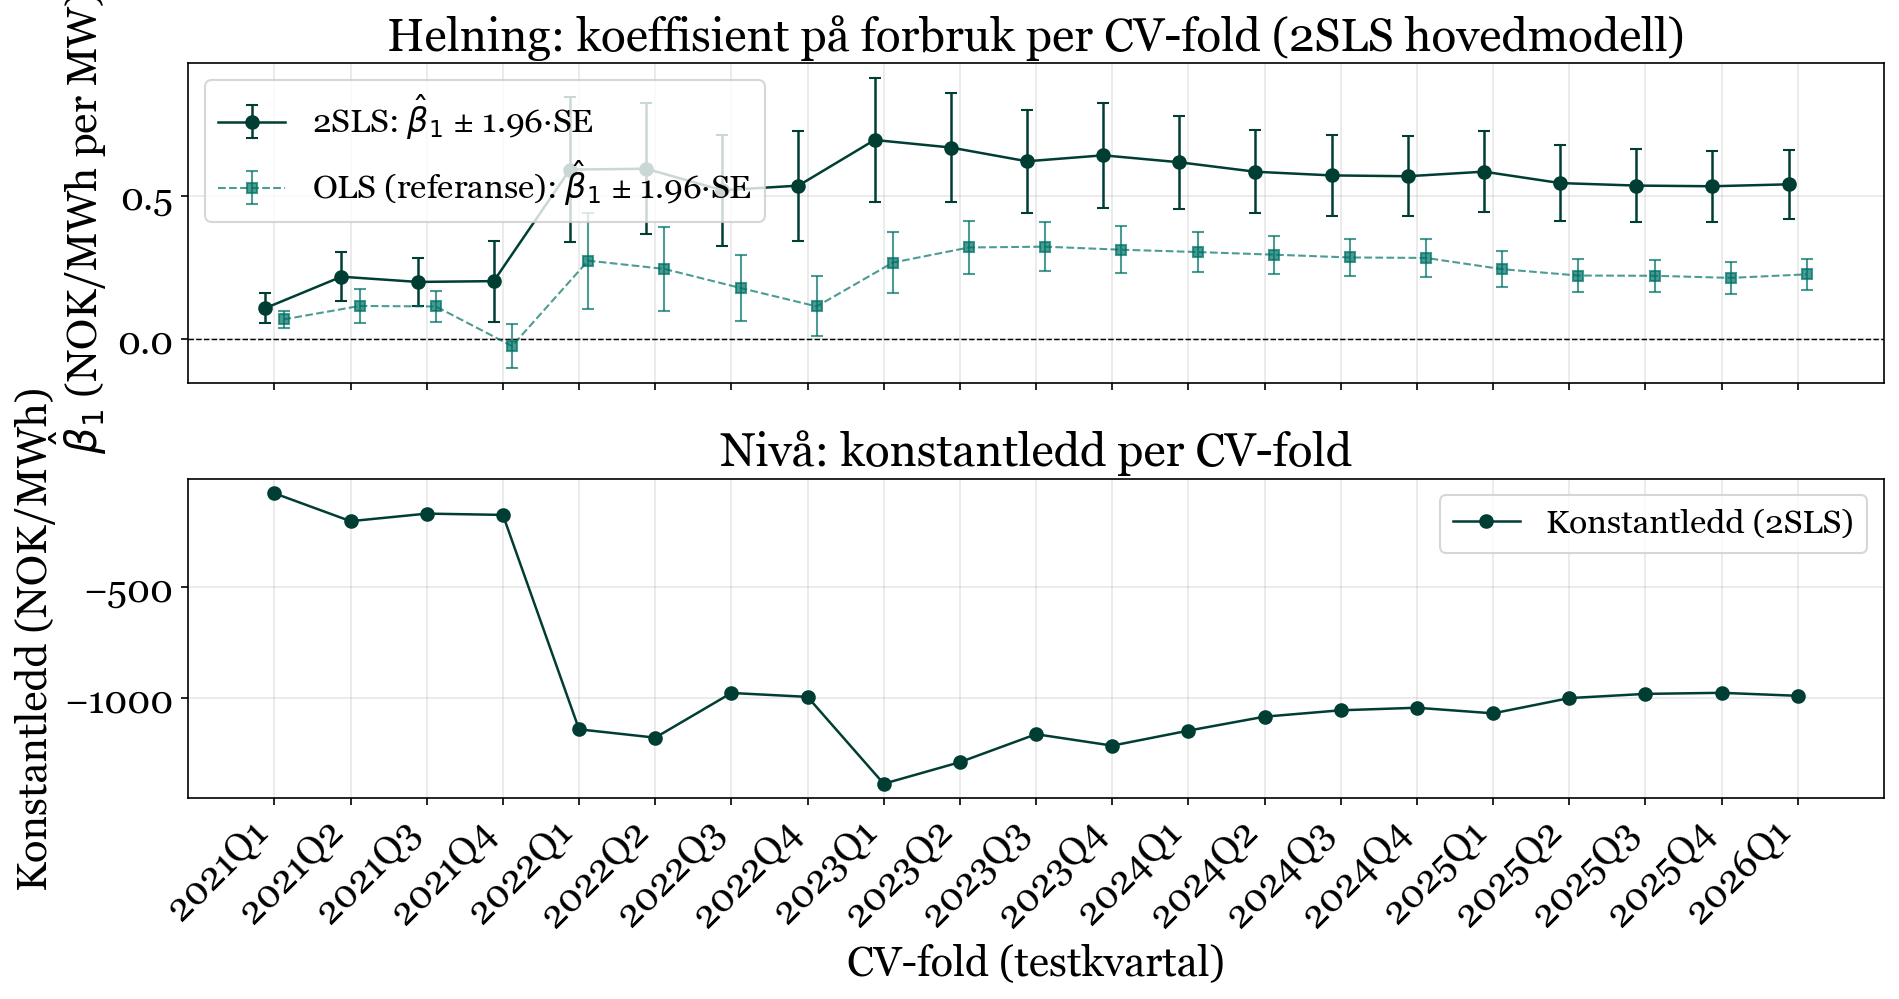

In [12]:
ok = coef_folds.dropna(subset=["beta_cons"]).reset_index(drop=True)
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

xs = np.arange(len(ok))
ci_iv = 1.96 * ok["se_cons"]
axes[0].errorbar(
    xs - 0.12, ok["beta_cons"], yerr=ci_iv,
    fmt="o-", color=C4, capsize=3, lw=1.2, markersize=6,
    label=r"2SLS: $\hat{\beta}_1$ ± 1.96·SE",
)
ci_ols = 1.96 * ok["se_cons_OLS"]
axes[0].errorbar(
    xs + 0.12, ok["beta_cons_OLS"], yerr=ci_ols,
    fmt="s--", color=C2, capsize=3, lw=1.0, markersize=5, alpha=0.7,
    label=r"OLS (referanse): $\hat{\beta}_1$ ± 1.96·SE",
)
axes[0].axhline(0, color="black", lw=0.7, ls="--")
axes[0].set_ylabel(r"$\hat{\beta}_1$ (NOK/MWh per MW)")
axes[0].set_title("Helning: koeffisient på forbruk per CV-fold (2SLS hovedmodell)")
axes[0].legend(loc="best")

axes[1].plot(xs, ok["konst"], "o-", color=C4, lw=1.2, markersize=6,
             label="Konstantledd (2SLS)")
axes[1].set_ylabel("Konstantledd (NOK/MWh)")
axes[1].set_xlabel("CV-fold (testkvartal)")
axes[1].set_title("Nivå: konstantledd per CV-fold")
axes[1].set_xticks(xs)
axes[1].set_xticklabels(ok["Test"], rotation=45, ha="right")
axes[1].legend(loc="best")

plt.tight_layout()
plt.savefig(f"{SEC07_DIR}coefficient_per_fold.pdf", bbox_inches="tight")
plt.show()


## Koeffisientstabilitet på tvers av strata

Forrige seksjoner viste stabilitet *på tvers av modeller* og *på tvers av år*. Her undersøkes om $\hat{\beta}_1$ er stabil *på tvers av delpopulasjoner* — sesong (vinter vs. sommer) og etterspørselsnivå (lav, normal, høy basert på terciler av `cons_NO4` i treningsperioden). OLS og 2SLS reestimeres på hver delpopulasjon, og resultatene vises som en to-panels skogplott. Den heltrukne vertikale linjen markerer hovedestimatet (Total) og den stiplede markerer null (ingen effekt).


In [13]:
from src.config import (
    OLS_FEATURES, IV_ENDOG, IV_INSTRUMENTS, IV_EXOG, TRAIN_YEARS,
)
from src.model_training import fit_2sls

df_train = df_iso[df_iso.index.year.isin(TRAIN_YEARS)].copy()
p33, p67 = df_train["cons_NO4"].quantile([0.33, 0.67]).values

def _demand_label(x):
    if x < p33:
        return "Lav"
    if x < p67:
        return "Normal"
    return "Høy"

df_train["_demand_level"] = df_train["cons_NO4"].apply(_demand_label)


def _fit_strata(df_sub, label):
    out = []
    if len(df_sub) < 200:
        print(f"Hopper over {label}: kun {len(df_sub)} timer")
        return out
    feat = [c for c in OLS_FEATURES if df_sub[c].nunique() > 1]
    exog = [c for c in IV_EXOG if df_sub[c].nunique() > 1]

    # Unngå dummytrappen: hvis månedsdummiene i utvalget alltid summerer til 1
    # (f.eks. sommer = kun måned 6/7/8), er de kollineære med konstantleddet.
    month_dummies = [c for c in exog if c.startswith("D_m")]
    if month_dummies and (df_sub[month_dummies].sum(axis=1) == 1).all():
        exog = [c for c in exog if c != month_dummies[-1]]
        feat = [c for c in feat if c != month_dummies[-1]]

    try:
        X = sm.add_constant(df_sub[feat].astype(float), has_constant="add")
        y = df_sub[TARGET].astype(float)
        m = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 24})
        b, se = float(m.params["cons_NO4"]), float(m.bse["cons_NO4"])
        out.append({"Stratum": label, "Modell": "OLS", "N": len(df_sub),
                    "beta": b, "SE": se, "ci_l": b - 1.96 * se, "ci_u": b + 1.96 * se,
                    "first_stage_F": np.nan, "partial_R2": np.nan})
    except Exception as e:
        print(f"OLS feilet for {label}: {e}")

    try:
        m, _ = fit_2sls(
            df_sub, y_col=TARGET, endog_col=IV_ENDOG,
            instrument_cols=IV_INSTRUMENTS, exog_cols=exog, hac_lags=24,
        )
        b = float(m.params["cons_NO4"])
        se = float(m.std_errors["cons_NO4"])
        fs_diag = m.first_stage.diagnostics.loc[IV_ENDOG]
        f_stat = float(fs_diag["f.stat"])
        partial_r2 = float(fs_diag["partial.rsquared"])
        out.append({"Stratum": label, "Modell": "2SLS", "N": len(df_sub),
                    "beta": b, "SE": se, "ci_l": b - 1.96 * se, "ci_u": b + 1.96 * se,
                    "first_stage_F": f_stat, "partial_R2": partial_r2})
    except Exception as e:
        print(f"2SLS feilet for {label}: {e}")
    return out


strata_rows = []
strata_rows += _fit_strata(df_train, "Total")
strata_rows += _fit_strata(df_train[df_train["season"] == "Winter"], "Vinter")
strata_rows += _fit_strata(df_train[df_train["season"] == "Summer"], "Sommer")
strata_rows += _fit_strata(df_train[df_train["_demand_level"] == "Lav"], "Lav (<P33)")
strata_rows += _fit_strata(df_train[df_train["_demand_level"] == "Normal"], "Normal (P33–P67)")
strata_rows += _fit_strata(df_train[df_train["_demand_level"] == "Høy"], "Høy (>P67)")

coef_strata = pd.DataFrame(strata_rows)

display_strata = pd.DataFrame({
    "Stratum":                  coef_strata["Stratum"],
    "Modell":                   coef_strata["Modell"],
    "N (timer)":                coef_strata["N"],
    "β̂₁ (NOK/MWh per MW)":     coef_strata["beta"].round(4),
    "SE":                       coef_strata["SE"].round(4),
    "95 % KI":                  coef_strata.apply(lambda r: f"[{r.ci_l:.3f}, {r.ci_u:.3f}]", axis=1),
})

print(f"Etterspørsel-terciler (treningsperiode): P33 = {p33:.0f} MW, P67 = {p67:.0f} MW")
print("Stratifiserte koeffisientestimater for cons_NO4:")
display(display_strata)

first_stage_table = (
    coef_strata[coef_strata["Modell"] == "2SLS"]
    [["Stratum", "N", "first_stage_F", "partial_R2"]]
    .assign(**{
        "Førstetrinn F":          lambda d: d["first_stage_F"].round(2),
        "Partial R²":             lambda d: d["partial_R2"].round(4),
        "Svake instrumenter?":    lambda d: np.where(d["first_stage_F"] < 10, "Ja (F < 10)", "Nei"),
    })
    [["Stratum", "N", "Førstetrinn F", "Partial R²", "Svake instrumenter?"]]
    .reset_index(drop=True)
)
print("\nFørstetrinns-F per stratum (2SLS, instrumenter: temp_NO4, precip_NO4):")
display(first_stage_table)
weak = first_stage_table[first_stage_table["Svake instrumenter?"].str.startswith("Ja")]
if not weak.empty:
    print("⚠ Svake instrumenter (F < 10) i strata:", ", ".join(weak["Stratum"]))
else:
    print("Ingen strata med svake instrumenter.")

coef_strata.to_parquet(f"{INTERMEDIATE_DIR}validation_coefficient_strata.parquet")
print(f"\nLagret {INTERMEDIATE_DIR}validation_coefficient_strata.parquet")


Etterspørsel-terciler (treningsperiode): P33 = 1974 MW, P67 = 2456 MW
Stratifiserte koeffisientestimater for cons_NO4:


,Stratum,Modell,N (timer),β̂₁ (NOK/MWh per MW),SE,95 % KI
0,Total,OLS,25072,0.3034,0.0361,"[0.233, 0.374]"
1,Total,2SLS,25072,0.6163,0.0823,"[0.455, 0.778]"
2,Vinter,OLS,6385,0.8283,0.1135,"[0.606, 1.051]"
3,Vinter,2SLS,6385,1.1846,0.2131,"[0.767, 1.602]"
4,Sommer,OLS,6688,-0.2029,0.0372,"[-0.276, -0.130]"
5,Sommer,2SLS,6688,0.3011,0.2218,"[-0.134, 0.736]"
6,Lav (<P33),OLS,8261,-0.2198,0.0467,"[-0.311, -0.128]"
7,Lav (<P33),2SLS,8261,1.3902,0.9130,"[-0.399, 3.180]"
8,Normal (P33–P67),OLS,8537,0.1320,0.0509,"[0.032, 0.232]"
9,Normal (P33–P67),2SLS,8537,0.1912,0.1302,"[-0.064, 0.446]"



Førstetrinns-F per stratum (2SLS, instrumenter: temp_NO4, precip_NO4):


,Stratum,N,Førstetrinn F,Partial R²,Svake instrumenter?
0,Total,25072,365.60,0.2340,Nei
1,Vinter,6385,217.30,0.3028,Nei
2,Sommer,6688,16.29,0.0423,Nei
3,Lav (<P33),8261,4.85,0.0098,Ja (F < 10)
4,Normal (P33–P67),8537,121.51,0.1420,Nei
5,Høy (>P67),8274,257.54,0.2115,Nei


⚠ Svake instrumenter (F < 10) i strata: Lav (<P33)

Lagret intermediate/validation_coefficient_strata.parquet


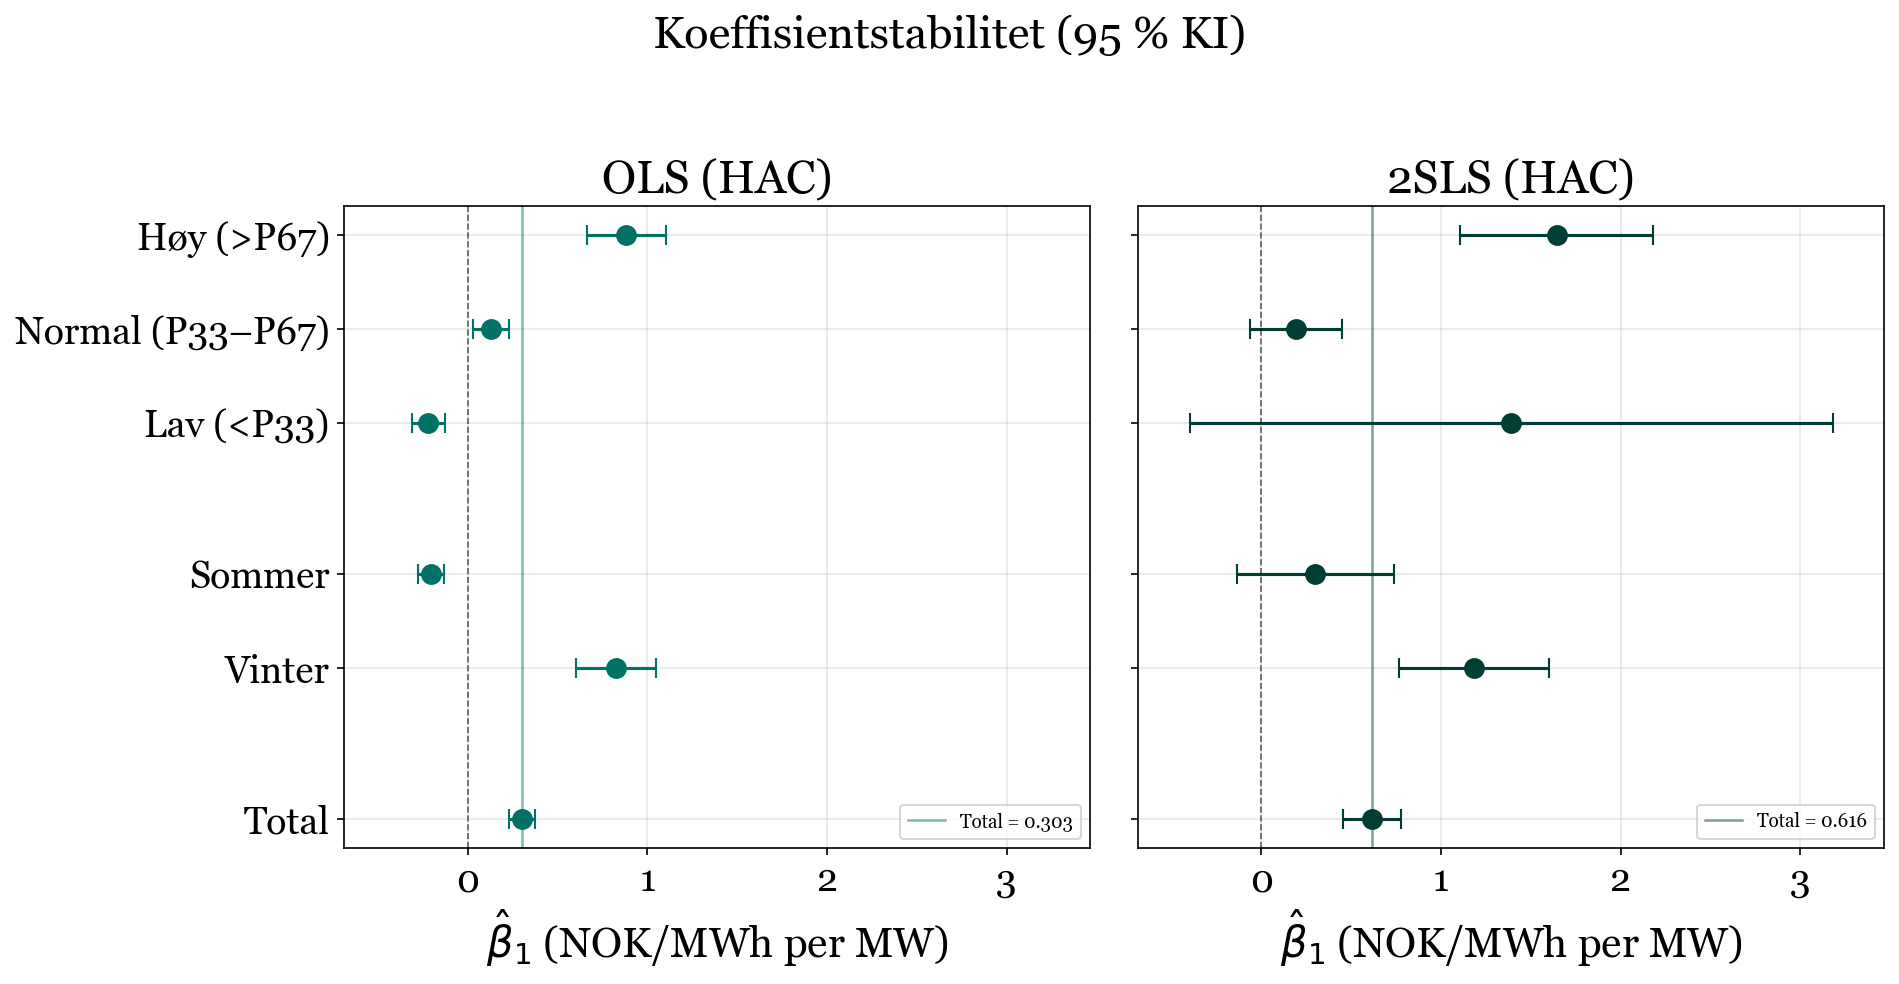

In [14]:
strata_order = ["Total", "Vinter", "Sommer", "Lav (<P33)", "Normal (P33–P67)", "Høy (>P67)"]
group_breaks = {"Vinter", "Lav (<P33)"}

y_positions, y = {}, 0.0
for s in strata_order:
    if s in group_breaks:
        y -= 0.6
    y_positions[s] = -y
    y -= 1.0

total_ols  = float(coef_strata[(coef_strata["Stratum"] == "Total") & (coef_strata["Modell"] == "OLS")]["beta"].iloc[0])
total_tsls = float(coef_strata[(coef_strata["Stratum"] == "Total") & (coef_strata["Modell"] == "2SLS")]["beta"].iloc[0])

fig, axes = plt.subplots(1, 2, figsize=(13, 6.5), sharey=True)

# Felles x-akse-intervall så panelene er direkte sammenlignbare
xmin = float(coef_strata["ci_l"].min())
xmax = float(coef_strata["ci_u"].max())
pad = 0.08 * (xmax - xmin)
xlim = (xmin - pad, xmax + pad)

for ax, model, color, total in [
    (axes[0], "OLS",  C2, total_ols),
    (axes[1], "2SLS", C4, total_tsls),
]:
    sub = coef_strata[coef_strata["Modell"] == model].set_index("Stratum")
    ys, betas, lo, hi = [], [], [], []
    for s in strata_order:
        if s not in sub.index:
            continue
        ys.append(y_positions[s])
        betas.append(sub.loc[s, "beta"])
        lo.append(sub.loc[s, "beta"] - sub.loc[s, "ci_l"])
        hi.append(sub.loc[s, "ci_u"] - sub.loc[s, "beta"])
    ax.errorbar(betas, ys, xerr=[lo, hi], fmt="o", capsize=5,
                color=color, markersize=9, lw=1.5)
    ax.axvline(0,     color="black", lw=0.8, ls="--", alpha=0.6)
    ax.axvline(total, color=color,   lw=1.2, ls="-",  alpha=0.5,
               label=f"Total = {total:.3f}")
    ax.set_yticks([y_positions[s] for s in strata_order])
    ax.set_yticklabels(strata_order)
    ax.set_xlabel(r"$\hat{\beta}_1$ (NOK/MWh per MW)")
    ax.set_title(f"{model} (HAC)")
    ax.legend(loc="lower right", fontsize=9, frameon=True)
    ax.grid(axis="x", alpha=0.3)
    ax.set_xlim(xlim)

fig.suptitle("Koeffisientstabilitet (95 % KI)", y=1.02)
plt.tight_layout()
plt.savefig(f"{SEC07_DIR}coefficient_strata_forest.pdf", bbox_inches="tight")
plt.show()


## Koeffisientstabilitet på tvers av ISO-typer

Strata-analysen over splitter på sesong og etterspørselsnivå, men behandler alle ISO-timer likt. ISO-perioder er ikke en homogen gruppe: noen oppstår fordi NO4 har lokalt overskudd og ville eksportert mer hvis kapasiteten tillot det (eksport-overskudd), mens andre oppstår fordi NO4 har lokal knapphet og ville importert mer hvis kapasiteten tillot det (import-knapphet). Disse to tilstandene har ulike implikasjoner for hvordan en marginal forbruksøkning fra Stargate Norway vil slå ut i prisen.

Hver ISO-time klassifiseres ved å sammenligne NO4-prisen mot medianen av nabosonepriser (NO3, SE1, SE2, FI):

- **ISO-import (`ISO_imp`)**: NO4-pris > median av nabopriser → lokal knapphet. NO4 ville importert mer fra naboene hvis transmisjonskapasiteten tillot det. Marginal forbruksøkning forventes å presse prisen klart oppover.
- **ISO-eksport (`ISO_exp`)**: NO4-pris ≤ median av nabopriser → lokalt overskudd. NO4 ville eksportert mer til naboene hvis transmisjonskapasiteten tillot det. Marginal forbruksøkning reduserer eksportoverskuddet, og priseffekten forventes å være nær null eller svakt negativ.

OLS (HAC) og 2SLS (HAC) reestimeres på hvert delsett. Resultatet vises i et to-panels skogplott med samme stil som forrige plot, der den heltrukne vertikale linjen markerer total-estimatet og den stiplede markerer null. Hvis en av tilstandene har for få timer til å identifisere modellen, hoppes estimeringen over og det rapporteres eksplisitt.

In [15]:
neighbor_price_cols = ["price_NO3", "price_SE1", "price_SE2", "price_FI"]
df_iso["neighbor_price_median"] = df_iso[neighbor_price_cols].median(axis=1)
df_iso["iso_type"] = np.where(
    df_iso[TARGET] > df_iso["neighbor_price_median"],
    "ISO_imp",
    "ISO_exp",
)

df_train_iso = df_iso[df_iso.index.year.isin(TRAIN_YEARS)].copy()
print("Fordeling av ISO-typer (treningsperiode 2020–2023):")
print(df_train_iso["iso_type"].value_counts())
print(f"Total: {len(df_train_iso):,} timer")

MIN_N_FOR_FIT = 200  # samme terskel som i strata-cellen

rows = []
for iso_type in ["ISO_imp", "ISO_exp"]:
    df_sub = df_train_iso[df_train_iso["iso_type"] == iso_type].copy()
    n = len(df_sub)
    if n < 1000:
        print(f"⚠ {iso_type}: kun {n} timer (< 1000) — estimater er usikre eller ikke identifiserbare")
    if n < MIN_N_FOR_FIT:
        print(f"   Hopper over estimering for {iso_type} (n={n} < {MIN_N_FOR_FIT}).")
        rows.append({"Tilstand": iso_type, "Modell": "OLS (HAC)", "N": n,
                     "beta": np.nan, "SE": np.nan, "ci_l": np.nan, "ci_u": np.nan,
                     "F_stat": np.nan, "Partial_R2": np.nan})
        rows.append({"Tilstand": iso_type, "Modell": "2SLS (HAC)", "N": n,
                     "beta": np.nan, "SE": np.nan, "ci_l": np.nan, "ci_u": np.nan,
                     "F_stat": np.nan, "Partial_R2": np.nan})
        continue

    feat_sub = [c for c in OLS_FEATURES if df_sub[c].nunique() > 1]
    exog_sub = [c for c in IV_EXOG if df_sub[c].nunique() > 1]

    # OLS (HAC, 24 lag)
    try:
        X = sm.add_constant(df_sub[feat_sub].astype(float), has_constant="add")
        y = df_sub[TARGET].astype(float)
        ols_sub = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 24})
        b, se = float(ols_sub.params["cons_NO4"]), float(ols_sub.bse["cons_NO4"])
        rows.append({"Tilstand": iso_type, "Modell": "OLS (HAC)", "N": n,
                     "beta": b, "SE": se, "ci_l": b - 1.96*se, "ci_u": b + 1.96*se,
                     "F_stat": np.nan, "Partial_R2": np.nan})
    except Exception as e:
        print(f"OLS feilet for {iso_type}: {e}")
        rows.append({"Tilstand": iso_type, "Modell": "OLS (HAC)", "N": n,
                     "beta": np.nan, "SE": np.nan, "ci_l": np.nan, "ci_u": np.nan,
                     "F_stat": np.nan, "Partial_R2": np.nan})

    # 2SLS (HAC, 24 lag)
    try:
        tsls_sub, _ = fit_2sls(
            df_sub, y_col=TARGET, endog_col=IV_ENDOG,
            instrument_cols=IV_INSTRUMENTS, exog_cols=exog_sub, hac_lags=24,
        )
        b = float(tsls_sub.params["cons_NO4"])
        se = float(tsls_sub.std_errors["cons_NO4"])
        fs_diag = tsls_sub.first_stage.diagnostics.loc[IV_ENDOG]
        f_stat = float(fs_diag["f.stat"])
        partial_r2 = float(fs_diag["partial.rsquared"])
        rows.append({"Tilstand": iso_type, "Modell": "2SLS (HAC)", "N": n,
                     "beta": b, "SE": se, "ci_l": b - 1.96*se, "ci_u": b + 1.96*se,
                     "F_stat": f_stat, "Partial_R2": partial_r2})
    except Exception as e:
        print(f"2SLS feilet for {iso_type}: {e}")
        rows.append({"Tilstand": iso_type, "Modell": "2SLS (HAC)", "N": n,
                     "beta": np.nan, "SE": np.nan, "ci_l": np.nan, "ci_u": np.nan,
                     "F_stat": np.nan, "Partial_R2": np.nan})

coef_iso = pd.DataFrame(rows)
coef_iso[f"Effekt {STARGATE_MW} MW"] = (coef_iso["beta"] * STARGATE_MW).round(1)

display_iso = pd.DataFrame({
    "Tilstand":                 coef_iso["Tilstand"],
    "Modell":                   coef_iso["Modell"],
    "N (timer)":                coef_iso["N"],
    "β̂₁ (NOK/MWh per MW)":     coef_iso["beta"].round(4),
    "SE":                       coef_iso["SE"].round(4),
    "95 % KI":                  coef_iso.apply(
        lambda r: "–" if pd.isna(r.ci_l) else f"[{r.ci_l:.3f}, {r.ci_u:.3f}]", axis=1),
    "Førstetrinn F":            coef_iso["F_stat"].round(2),
    "Partial R²":               coef_iso["Partial_R2"].round(4),
    f"Effekt {STARGATE_MW} MW": coef_iso[f"Effekt {STARGATE_MW} MW"],
})

print("\nKoeffisientestimater per ISO-type:")
display(display_iso)

weak_iso = coef_iso[(coef_iso["Modell"] == "2SLS (HAC)") & (coef_iso["F_stat"] < 10)]
if not weak_iso.empty:
    print("⚠ Svake instrumenter (F < 10) i:", ", ".join(weak_iso["Tilstand"]))
else:
    print("Ingen ISO-typer med tilstrekkelig data har svake instrumenter.")

coef_iso.to_parquet(f"{INTERMEDIATE_DIR}validation_coefficient_iso_type.parquet")
print(f"\nLagret {INTERMEDIATE_DIR}validation_coefficient_iso_type.parquet")

Fordeling av ISO-typer (treningsperiode 2020–2023):
iso_type
ISO_exp    25059
ISO_imp       13
Name: count, dtype: int64
Total: 25,072 timer
⚠ ISO_imp: kun 13 timer (< 1000) — estimater er usikre eller ikke identifiserbare
   Hopper over estimering for ISO_imp (n=13 < 200).

Koeffisientestimater per ISO-type:


,Tilstand,Modell,N (timer),β̂₁ (NOK/MWh per MW),SE,95 % KI,Førstetrinn F,Partial R²,Effekt 230 MW
0,ISO_imp,OLS (HAC),13,NaN,NaN,–,NaN,NaN,NaN
1,ISO_imp,2SLS (HAC),13,NaN,NaN,–,NaN,NaN,NaN
2,ISO_exp,OLS (HAC),25059,0.3035,0.0361,"[0.233, 0.374]",NaN,NaN,69.8
3,ISO_exp,2SLS (HAC),25059,0.6166,0.0823,"[0.455, 0.778]",365.41,0.234,141.8


Ingen ISO-typer med tilstrekkelig data har svake instrumenter.

Lagret intermediate/validation_coefficient_iso_type.parquet


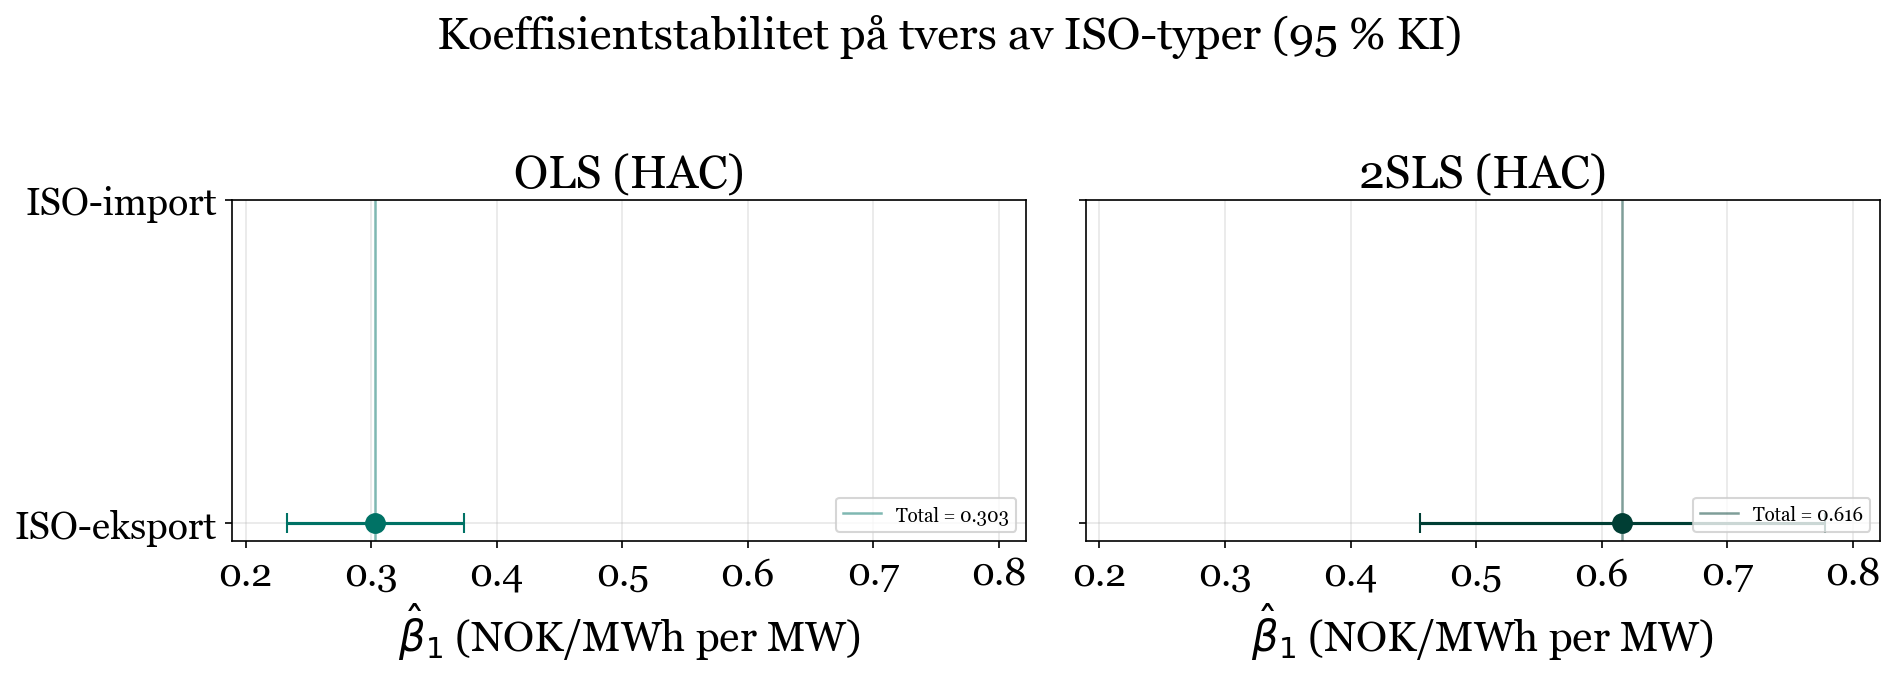

In [16]:
iso_order = ["ISO_imp", "ISO_exp"]
iso_labels = {"ISO_imp": "ISO-import", "ISO_exp": "ISO-eksport"}

total_ols_iso  = float(coef_strata[(coef_strata["Stratum"] == "Total") & (coef_strata["Modell"] == "OLS")]["beta"].iloc[0])
total_tsls_iso = float(coef_strata[(coef_strata["Stratum"] == "Total") & (coef_strata["Modell"] == "2SLS")]["beta"].iloc[0])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

xmin = float(coef_iso["ci_l"].min())
xmax = float(coef_iso["ci_u"].max())
pad  = 0.08 * (xmax - xmin)
xlim = (xmin - pad, xmax + pad)

y_positions = {iso: -i for i, iso in enumerate(iso_order)}

for ax, model, color, total in [
    (axes[0], "OLS (HAC)",  C2, total_ols_iso),
    (axes[1], "2SLS (HAC)", C4, total_tsls_iso),
]:
    sub = coef_iso[coef_iso["Modell"] == model].set_index("Tilstand")
    ys, betas, lo, hi = [], [], [], []
    for s in iso_order:
        if s not in sub.index:
            continue
        ys.append(y_positions[s])
        betas.append(sub.loc[s, "beta"])
        lo.append(sub.loc[s, "beta"] - sub.loc[s, "ci_l"])
        hi.append(sub.loc[s, "ci_u"] - sub.loc[s, "beta"])
    ax.errorbar(betas, ys, xerr=[lo, hi], fmt="o", capsize=5,
                color=color, markersize=9, lw=1.5)
    ax.axvline(0,     color="black", lw=0.8, ls="--", alpha=0.6)
    ax.axvline(total, color=color,   lw=1.2, ls="-",  alpha=0.5,
               label=f"Total = {total:.3f}")
    ax.set_yticks([y_positions[s] for s in iso_order])
    ax.set_yticklabels([iso_labels[s] for s in iso_order])
    ax.set_xlabel(r"$\hat{\beta}_1$ (NOK/MWh per MW)")
    ax.set_title(f"{model.replace(' (HAC)', '')} (HAC)")
    ax.legend(loc="lower right", fontsize=9, frameon=True)
    ax.grid(axis="x", alpha=0.3)
    ax.set_xlim(xlim)

fig.suptitle("Koeffisientstabilitet på tvers av ISO-typer (95 % KI)", y=1.02)
plt.tight_layout()
plt.savefig(f"{SEC07_DIR}coefficient_iso_type_forest.pdf", bbox_inches="tight")
plt.show()

## 4.3 OLS

OLS valideres både som prediksjonsmodell og som tolkbar strukturmodell. Derfor brukes både out-of-sample metrikker og klassiske residualdiagnostiske tester.


In [17]:
X_train, y_train, X_test, y_test, train_mask, test_mask = split_features_target(
    df_iso,
    feature_cols=OLS_FEATURES,
    target=TARGET,
    train_years=TRAIN_YEARS,
    test_years=TEST_YEARS,
)

X_train_c = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train_c).fit(cov_type="HAC", cov_kwds={"maxlags": 24})
train_resid = ols_model.resid
train_acf = compute_acf(train_resid, nlags=48, fft=True)
bp_lm, bp_pval, _, _ = het_breuschpagan(train_resid, X_train_c)
dw_stat = durbin_watson(train_resid)
adf_stat, adf_pval, *_ = adfuller(train_resid.dropna())

ols_diag = pd.DataFrame([
    {"Test": "Breusch-Pagan", "Verdi": bp_lm, "p-verdi": bp_pval},
    {"Test": "Durbin-Watson", "Verdi": dw_stat, "p-verdi": np.nan},
    {"Test": "ADF residualer", "Verdi": adf_stat, "p-verdi": adf_pval},
])
ols_bias = bias_total[bias_total["Modell"] == MODEL_LABELS["OLS"]]
ols_tail = tail_total[tail_total["Modell"] == MODEL_LABELS["OLS"]]
ols_levels = price_level_metrics[price_level_metrics["Modell"] == MODEL_LABELS["OLS"]]

print("OLS — total ytelse:")
display(metrics_total[metrics_total["Modell"] == MODEL_LABELS["OLS"]])
print("OLS — bias:")
display(ols_bias)
print("OLS — ytelse i høye pristimer:")
display(ols_tail)
print("OLS — ytelse per prisnivå:")
display(ols_levels.round(2))
print("OLS — diagnostikk på treningsresidualer:")
display(ols_diag.round(4))


OLS — total ytelse:


,Modell,MAE,RMSE,R²,N
4,OLS (HAC),154.6,222.8,0.2425,9844


OLS — bias:


,Modell,ME,Medianfeil,MAPE
1,OLS (HAC),53.76,68.09,304.92


OLS — ytelse i høye pristimer:


,Modell,MAE,RMSE,R²,N
5,OLS (HAC),357.0,478.3,-1.4558,985


OLS — ytelse per prisnivå:


,Prisnivå,Modell,MAE,RMSE,R²,N
1,Høy pris,OLS (HAC),170.1,278.3,-0.26,3282
9,Lav pris,OLS (HAC),104.7,131.0,-43.05,3281
17,Normal pris,OLS (HAC),188.9,233.0,-11.85,3281


OLS — diagnostikk på treningsresidualer:


,Test,Verdi,p-verdi
0,Breusch-Pagan,964.0848,0.0
1,Durbin-Watson,0.1093,NaN
2,ADF residualer,-10.1996,0.0


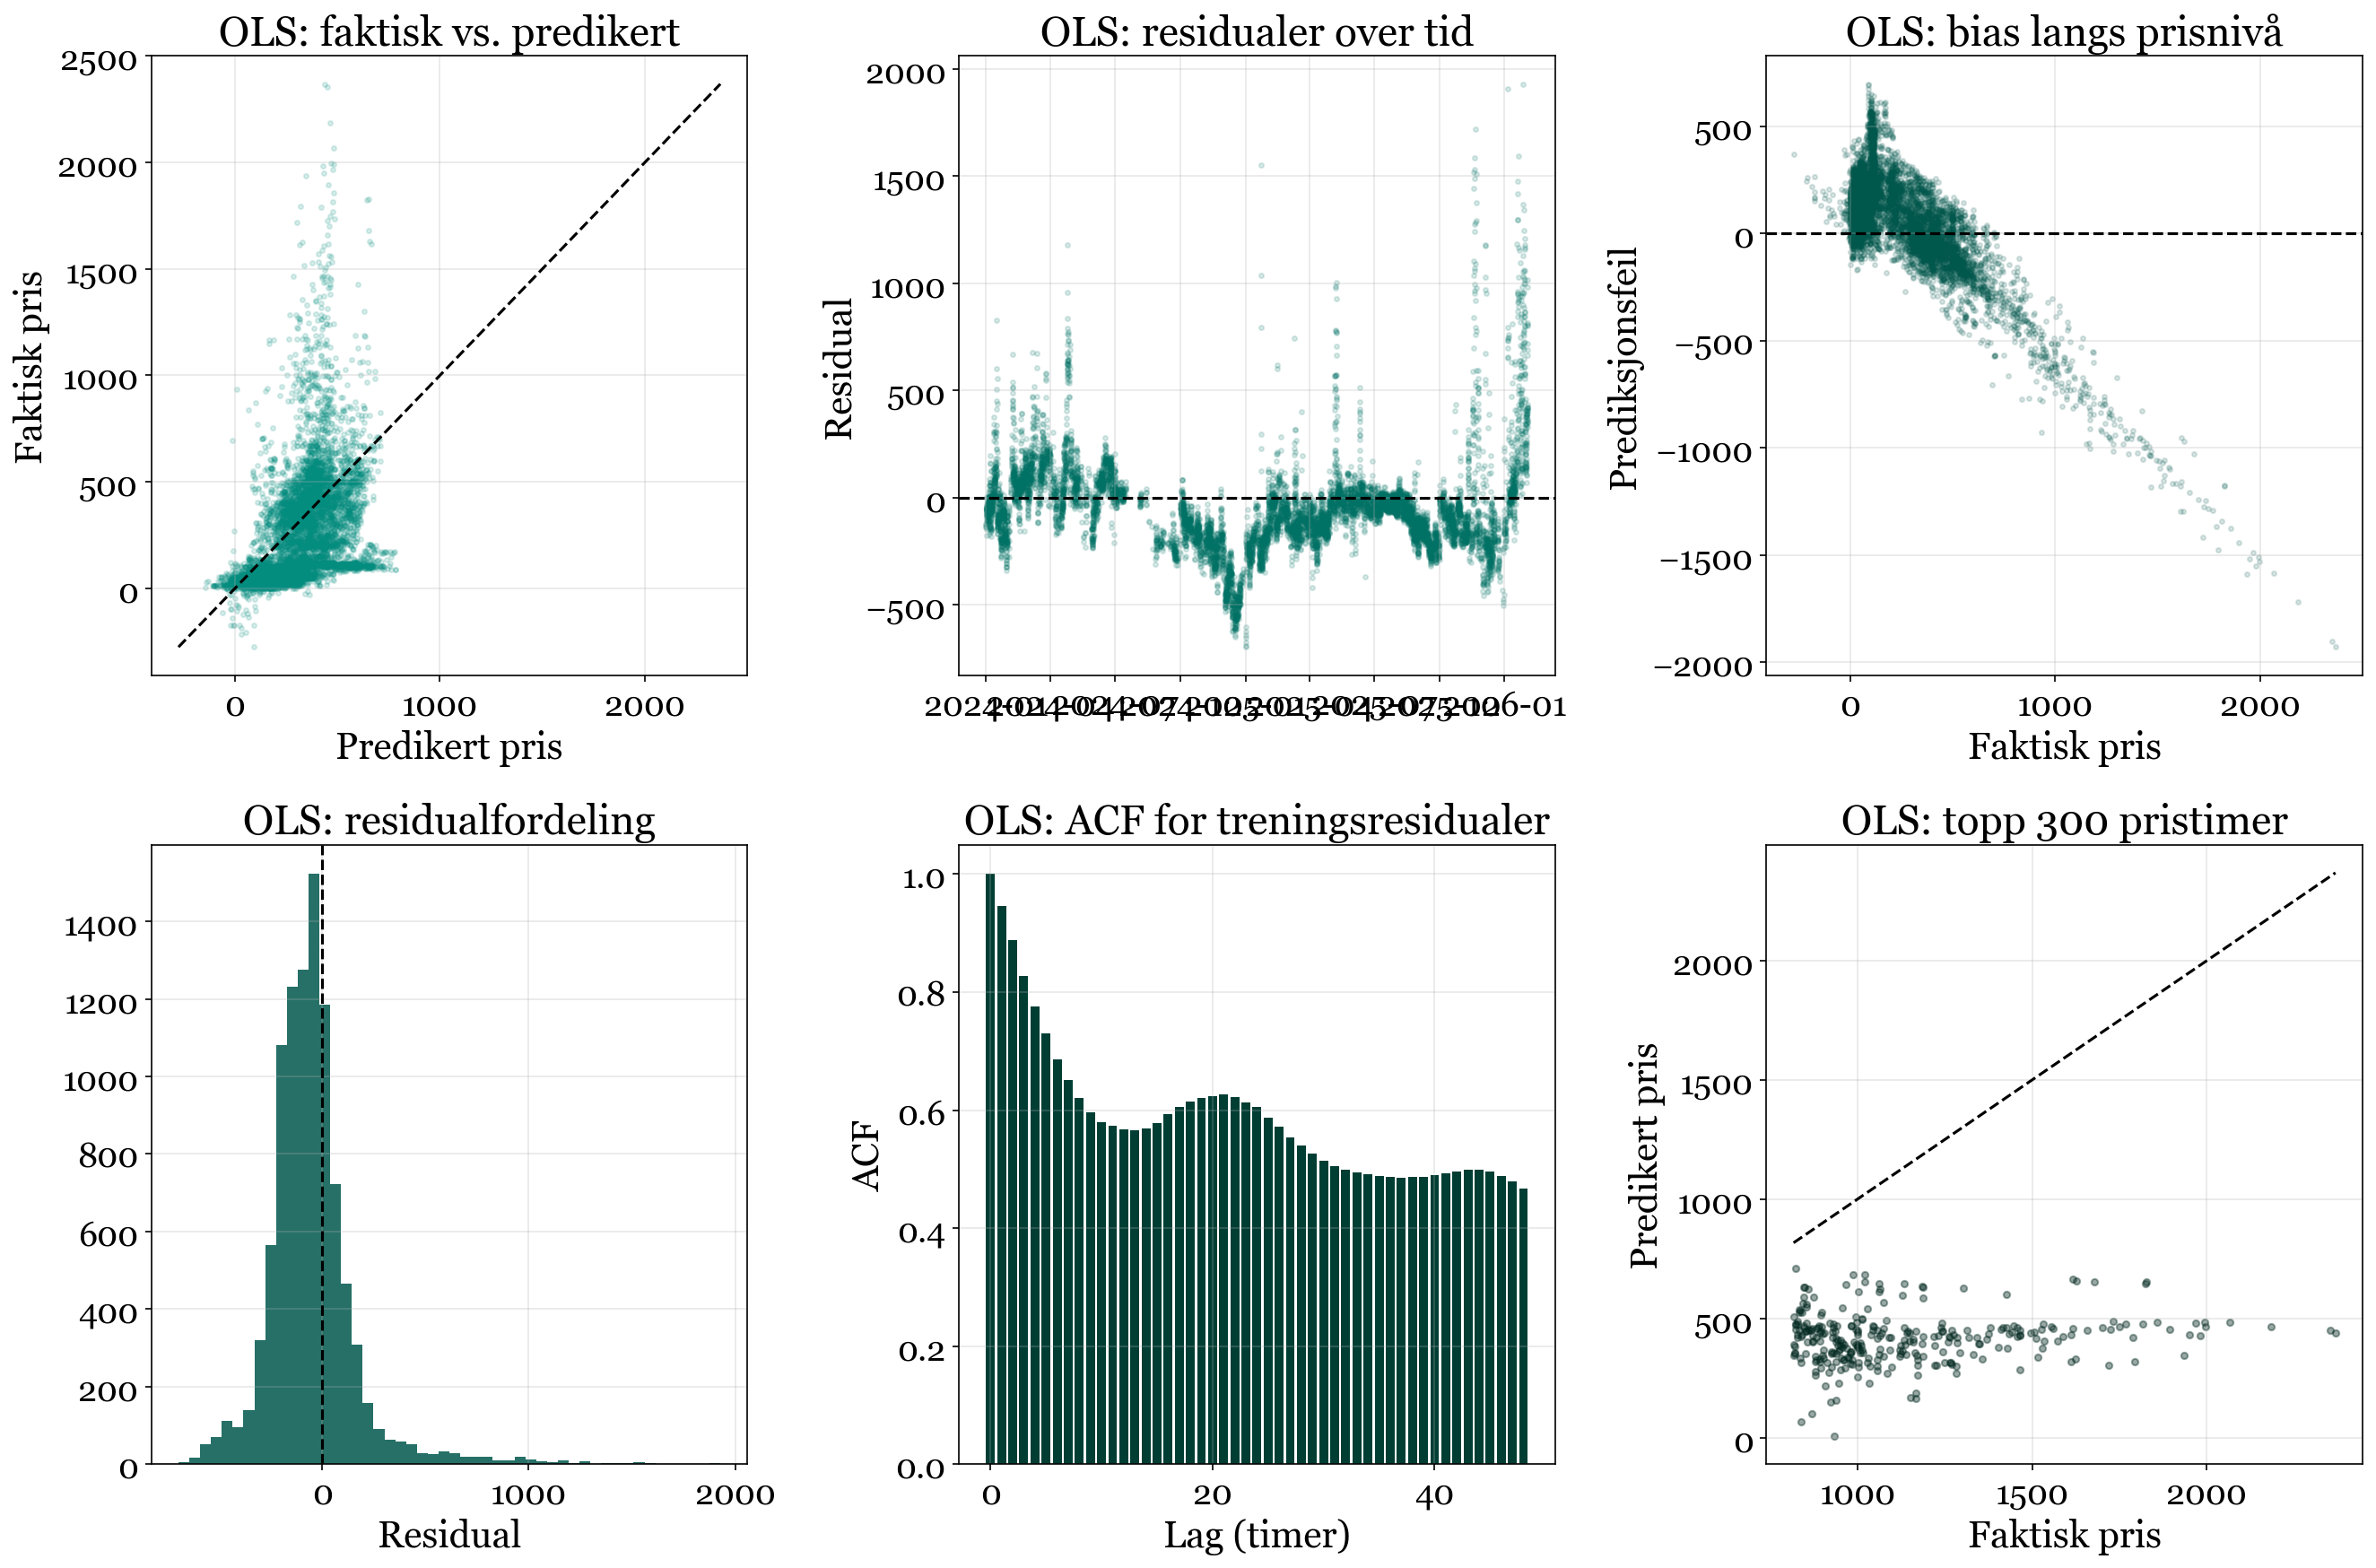

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

line_min = min(df_preds["actual"].min(), df_preds["OLS"].min())
line_max = max(df_preds["actual"].max(), df_preds["OLS"].max())

axes[0, 0].scatter(df_preds["OLS"], df_preds["actual"], s=6, alpha=0.15, color=C1)
axes[0, 0].plot([line_min, line_max], [line_min, line_max], color="black", ls="--")
axes[0, 0].set_xlabel("Predikert pris")
axes[0, 0].set_ylabel("Faktisk pris")
axes[0, 0].set_title("OLS: faktisk vs. predikert")

axes[0, 1].scatter(df_preds.index, df_preds["resid_OLS"], s=6, alpha=0.15, color=C2)
axes[0, 1].axhline(0, color="black", ls="--")
axes[0, 1].set_ylabel("Residual")
axes[0, 1].set_title("OLS: residualer over tid")

axes[0, 2].scatter(df_preds["actual"], df_preds["OLS"] - df_preds["actual"], s=6, alpha=0.15, color=C3)
axes[0, 2].axhline(0, color="black", ls="--")
axes[0, 2].set_xlabel("Faktisk pris")
axes[0, 2].set_ylabel("Prediksjonsfeil")
axes[0, 2].set_title("OLS: bias langs prisnivå")

axes[1, 0].hist(df_preds["resid_OLS"].dropna(), bins=50, color=C3, alpha=0.85)
axes[1, 0].axvline(0, color="black", ls="--")
axes[1, 0].set_xlabel("Residual")
axes[1, 0].set_title("OLS: residualfordeling")

axes[1, 1].bar(range(len(train_acf)), train_acf, color=C4, width=0.8)
axes[1, 1].set_xlabel("Lag (timer)")
axes[1, 1].set_ylabel("ACF")
axes[1, 1].set_title("OLS: ACF for treningsresidualer")

ols_top = df_preds.nlargest(300, "actual")
axes[1, 2].scatter(ols_top["actual"], ols_top["OLS"], s=12, alpha=0.4, color=C5)
axes[1, 2].plot([ols_top["actual"].min(), ols_top["actual"].max()],
                [ols_top["actual"].min(), ols_top["actual"].max()], color="black", ls="--")
axes[1, 2].set_xlabel("Faktisk pris")
axes[1, 2].set_ylabel("Predikert pris")
axes[1, 2].set_title("OLS: topp 300 pristimer")

plt.tight_layout()
plt.savefig(f"{SEC07_DIR}ols_validation.pdf", bbox_inches="tight")
plt.show()


In [19]:
print("OLS — kort tolkning:")
print("- Viser hvordan den tolkbare hovedmodellen presterer out-of-sample.")
print("- Residualdiagnostikken brukes for å dokumentere seriekorrelasjon og heteroskedastisitet.")
print("- Tail- og bias-plottene viser om modellen underreagerer i høye pristimer.")


OLS — kort tolkning:
- Viser hvordan den tolkbare hovedmodellen presterer out-of-sample.
- Residualdiagnostikken brukes for å dokumentere seriekorrelasjon og heteroskedastisitet.
- Tail- og bias-plottene viser om modellen underreagerer i høye pristimer.


## 4.4 XGBoost

XGBoost valideres primært som en prediktiv modell. Fokus er derfor på total ytelse, stabilitet over tid, systematisk bias og hvor godt modellen håndterer høye priser.


In [20]:
xgb_bias = bias_total[bias_total["Modell"] == MODEL_LABELS["XGB"]]
xgb_tail = tail_total[tail_total["Modell"] == MODEL_LABELS["XGB"]]
xgb_levels = price_level_metrics[price_level_metrics["Modell"] == MODEL_LABELS["XGB"]]
df_preds["roll_mae_XGB"] = rolling_mae(df_preds["actual"], df_preds["XGB"], window=24 * 7)

print("XGBoost — total ytelse:")
display(metrics_total[metrics_total["Modell"] == MODEL_LABELS["XGB"]])
print("XGBoost — bias:")
display(xgb_bias)
print("XGBoost — ytelse i høye pristimer:")
display(xgb_tail)
print("XGBoost — ytelse per prisnivå:")
display(xgb_levels.round(2))
print("XGBoost — ytelse per år:")
display(metrics_year[metrics_year["Modell"] == MODEL_LABELS["XGB"]].round(2))


XGBoost — total ytelse:


,Modell,MAE,RMSE,R²,N
5,XGBoost,180.7,264.5,-0.0679,9844


XGBoost — bias:


,Modell,ME,Medianfeil,MAPE
2,XGBoost,-3.08,32.07,314.26


XGBoost — ytelse i høye pristimer:


,Modell,MAE,RMSE,R²,N
7,XGBoost,462.9,544.1,-2.1783,985


XGBoost — ytelse per prisnivå:


,Prisnivå,Modell,MAE,RMSE,R²,N
2,Høy pris,XGBoost,276.3,350.5,-1.01,3282
10,Lav pris,XGBoost,96.9,119.9,-35.91,3281
18,Normal pris,XGBoost,168.7,269.6,-16.21,3281


XGBoost — ytelse per år:


,Segment,Modell,MAE,RMSE,R²,N
2,2024,XGBoost,246.0,316.8,-1.42,4033
10,2025,XGBoost,109.0,159.5,0.30,5322
18,2026,XGBoost,421.0,551.4,-0.98,489


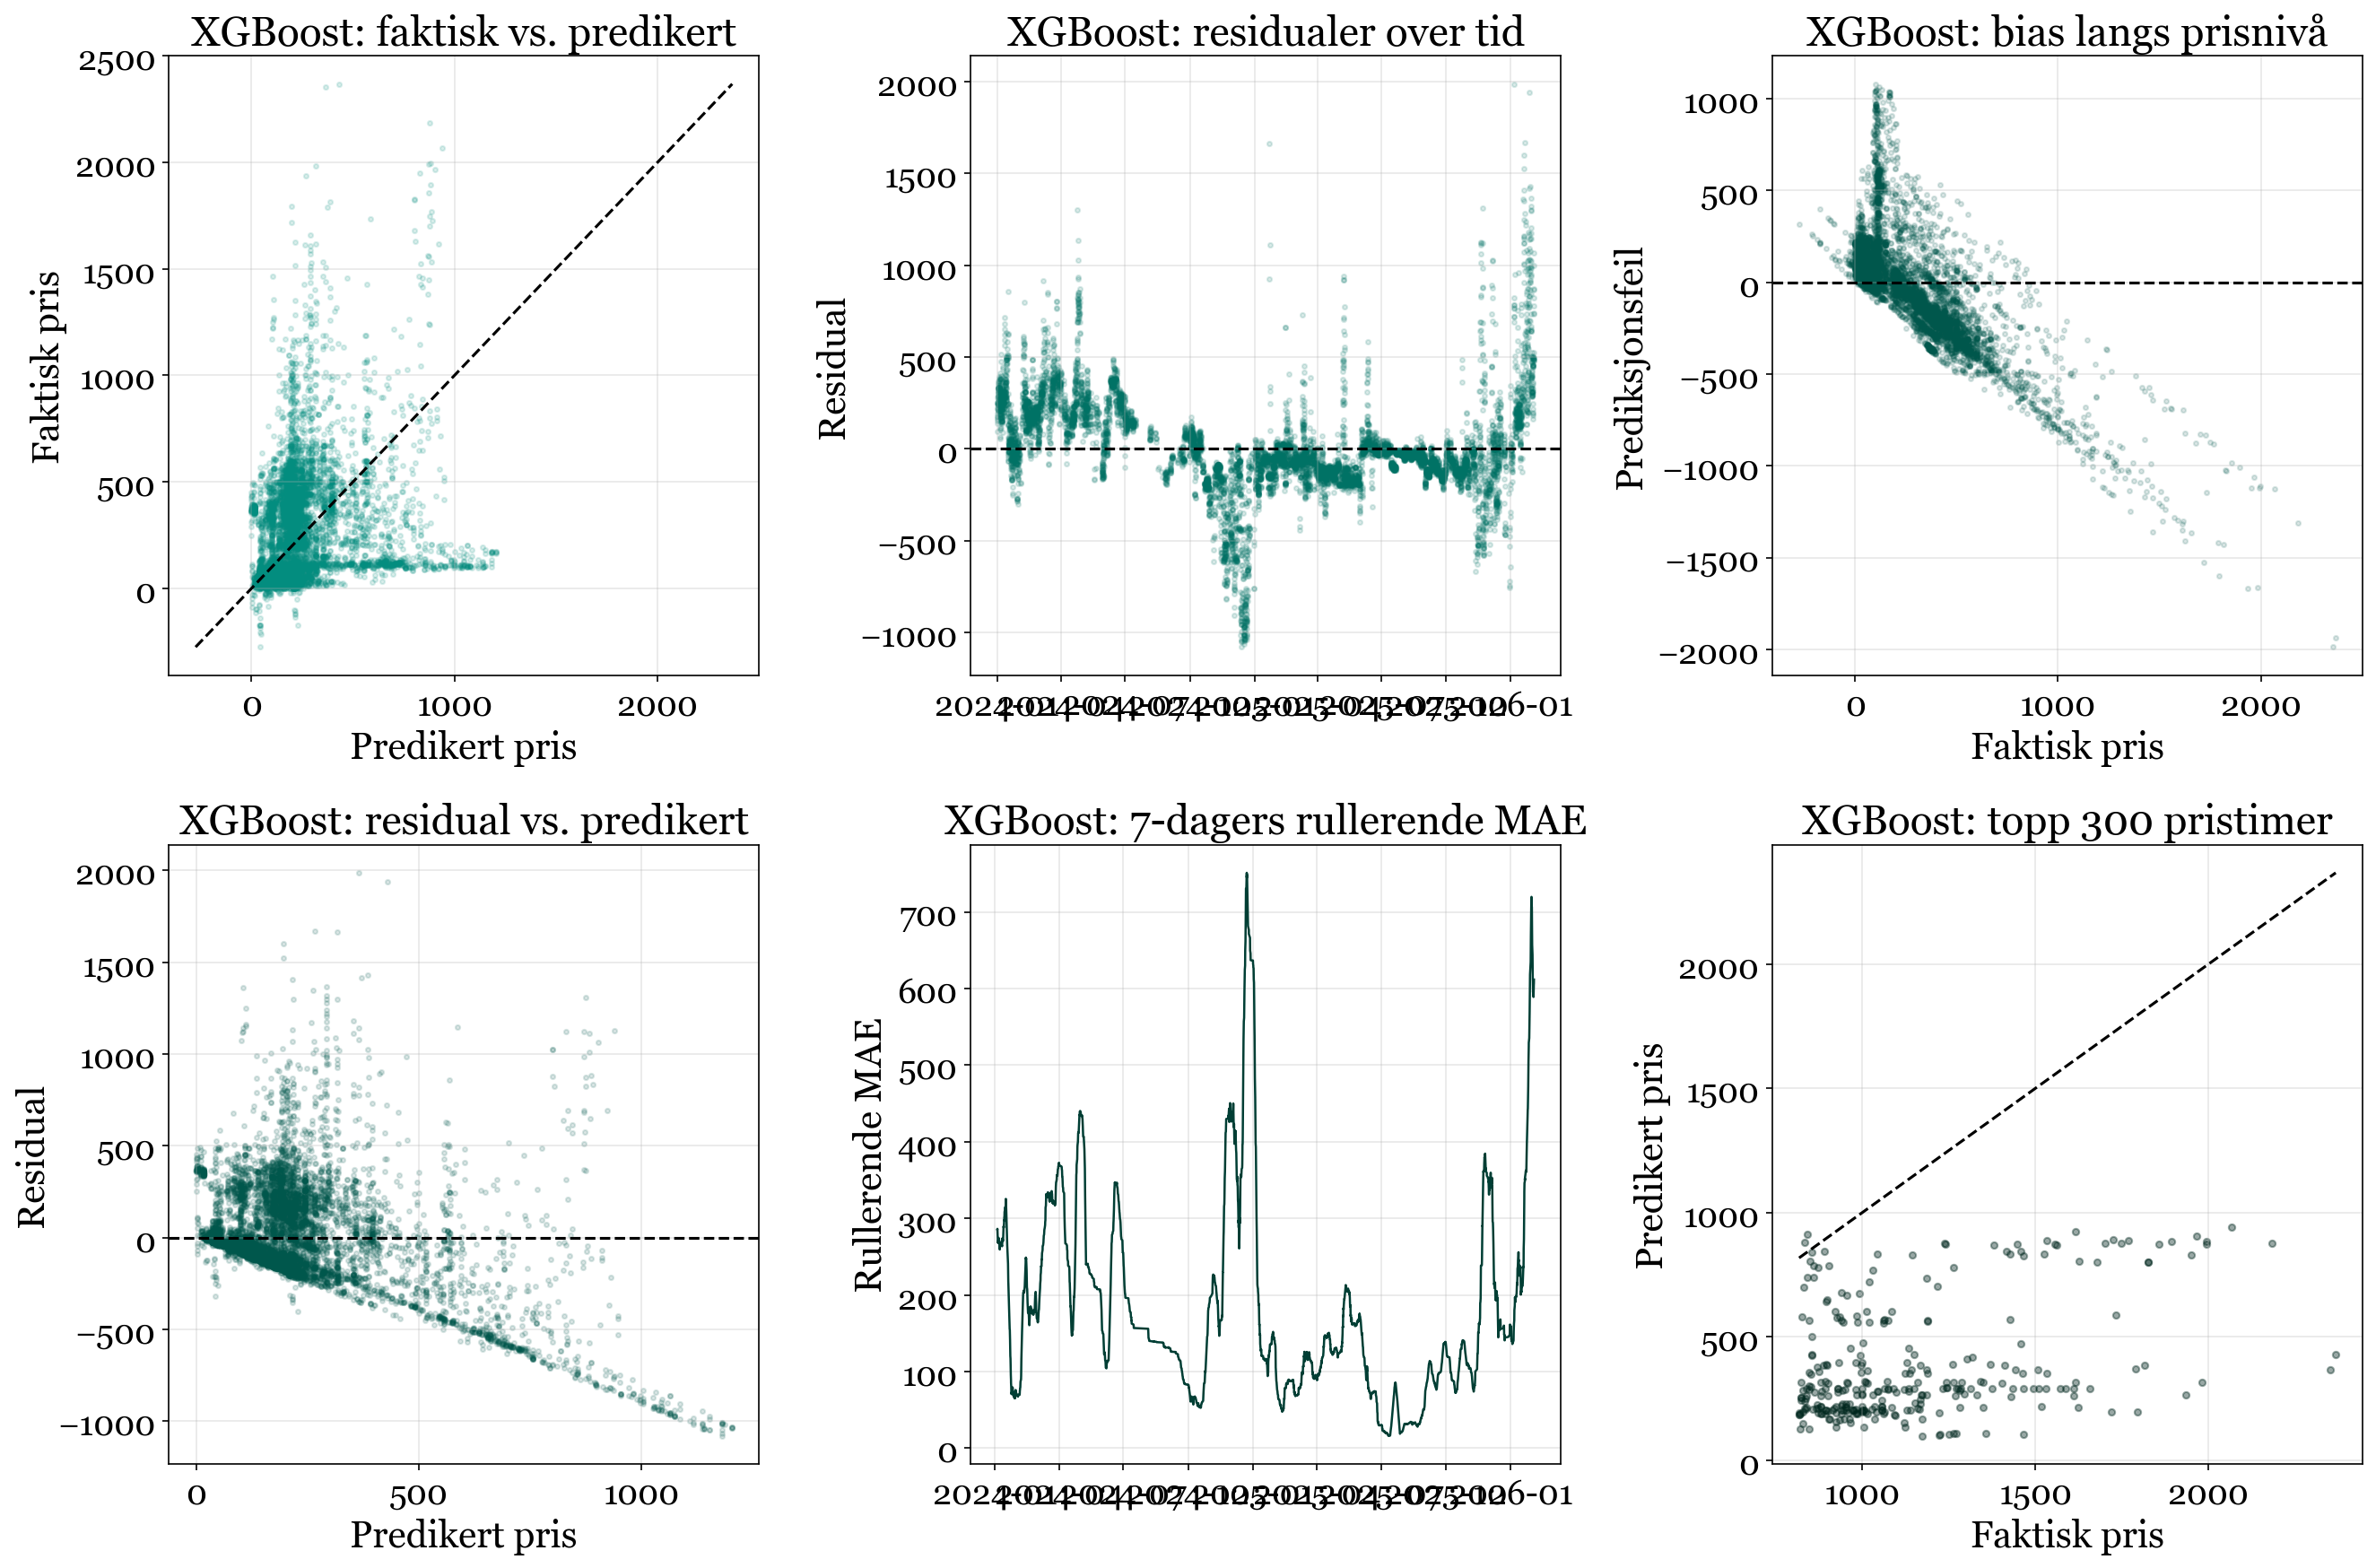

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

line_min = min(df_preds["actual"].min(), df_preds["XGB"].min())
line_max = max(df_preds["actual"].max(), df_preds["XGB"].max())

axes[0, 0].scatter(df_preds["XGB"], df_preds["actual"], s=6, alpha=0.15, color=C1)
axes[0, 0].plot([line_min, line_max], [line_min, line_max], color="black", ls="--")
axes[0, 0].set_xlabel("Predikert pris")
axes[0, 0].set_ylabel("Faktisk pris")
axes[0, 0].set_title("XGBoost: faktisk vs. predikert")

axes[0, 1].scatter(df_preds.index, df_preds["resid_XGB"], s=6, alpha=0.15, color=C2)
axes[0, 1].axhline(0, color="black", ls="--")
axes[0, 1].set_ylabel("Residual")
axes[0, 1].set_title("XGBoost: residualer over tid")

axes[0, 2].scatter(df_preds["actual"], df_preds["XGB"] - df_preds["actual"], s=6, alpha=0.15, color=C3)
axes[0, 2].axhline(0, color="black", ls="--")
axes[0, 2].set_xlabel("Faktisk pris")
axes[0, 2].set_ylabel("Prediksjonsfeil")
axes[0, 2].set_title("XGBoost: bias langs prisnivå")

axes[1, 0].scatter(df_preds["XGB"], df_preds["resid_XGB"], s=6, alpha=0.15, color=C3)
axes[1, 0].axhline(0, color="black", ls="--")
axes[1, 0].set_xlabel("Predikert pris")
axes[1, 0].set_ylabel("Residual")
axes[1, 0].set_title("XGBoost: residual vs. predikert")

axes[1, 1].plot(df_preds.index, df_preds["roll_mae_XGB"], color=C4, lw=1.2)
axes[1, 1].set_ylabel("Rullerende MAE")
axes[1, 1].set_title("XGBoost: 7-dagers rullerende MAE")

xgb_top = df_preds.nlargest(300, "actual")
axes[1, 2].scatter(xgb_top["actual"], xgb_top["XGB"], s=12, alpha=0.4, color=C5)
axes[1, 2].plot([xgb_top["actual"].min(), xgb_top["actual"].max()],
                [xgb_top["actual"].min(), xgb_top["actual"].max()], color="black", ls="--")
axes[1, 2].set_xlabel("Faktisk pris")
axes[1, 2].set_ylabel("Predikert pris")
axes[1, 2].set_title("XGBoost: topp 300 pristimer")

plt.tight_layout()
plt.savefig(f"{SEC07_DIR}xgb_validation.pdf", bbox_inches="tight")
plt.show()


In [22]:
print("XGBoost — kort tolkning:")
print("- Valideres som ren prediktiv modell, ikke som inferensmodell.")
print("- Bias- og tail-plottene er viktige for å se om modellen bommer systematisk på pristopper.")
print("- Rullerende MAE viser om ytelsen er stabil eller forverres i enkelte perioder.")


XGBoost — kort tolkning:
- Valideres som ren prediktiv modell, ikke som inferensmodell.
- Bias- og tail-plottene er viktige for å se om modellen bommer systematisk på pristopper.
- Rullerende MAE viser om ytelsen er stabil eller forverres i enkelte perioder.


## Krysstabell magasin × regime (vedlegg)

Som diskutert i resultatdelen er sammenhengen mellom magasinfyllingsgrad og lokal
priseffekt i stor grad mediert av prisregime: lavt magasinnivå er korrelert med
pristaker- og systemintegrerte timer (etterspørselen møtes ved import), mens høyt
magasinnivå er korrelert med isolerte/bindende timer (etterspørselen må møtes
lokalt). Tabellen og figuren under viser fordelingen av regimer betinget på
magasinnivå (terciler), og er ment som vedleggsmateriale som underbygger denne
mekanismen.

regime_group       ISO  CONG  PRICE_TAKER   SYS  UNCERTAIN
fill_bin                                                  
Lav (<58%)        61.2   7.7          6.8  24.1        0.3
Middels (58–79%)  64.4   9.5         10.2  14.0        1.9
Høy (>79%)        70.6   6.4          7.0  12.9        3.1


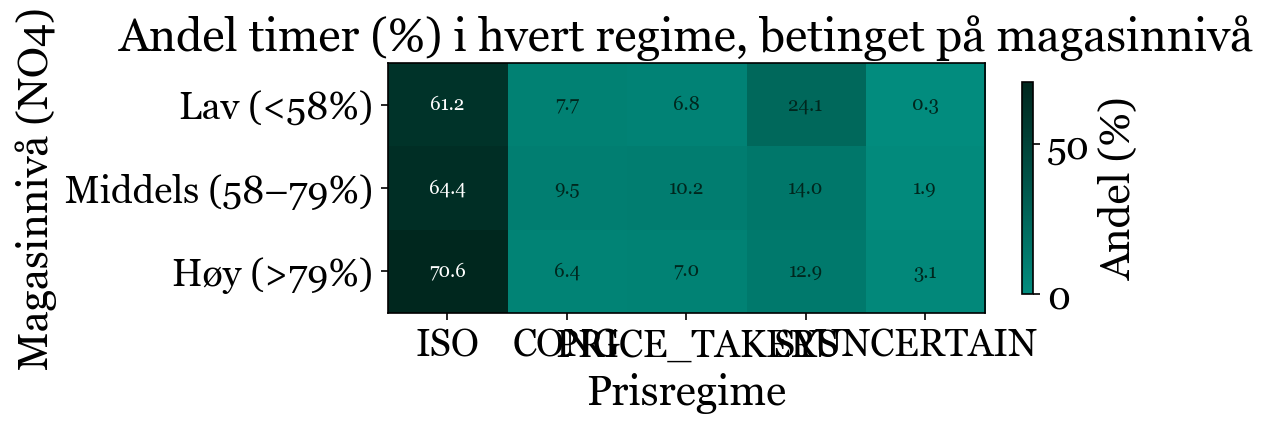


LaTeX-tabell lagret til: ../figures/notebook/04/krysstab_magasin_regime.tex


In [23]:
from matplotlib.colors import LinearSegmentedColormap

# Last fullt datasett (alle regimer, ikke bare ISO)
df_full = pd.read_parquet(f"{INTERMEDIATE_DIR}df_processed.parquet")

# Bin fyllingsgrad i tre nivåer (terciler over hele analyseperioden)
q33, q67 = df_full["fill_rate"].quantile([1/3, 2/3])
bins   = [-np.inf, q33, q67, np.inf]
labels = [f"Lav (<{q33*100:.0f}%)", f"Middels ({q33*100:.0f}–{q67*100:.0f}%)", f"Høy (>{q67*100:.0f}%)"]
df_full["fill_bin"] = pd.cut(df_full["fill_rate"], bins=bins, labels=labels)

# Krysstabell: andel timer (%) i hvert regime, betinget på magasinnivå
regime_order = ["ISO", "CONG", "PRICE_TAKER", "SYS", "UNCERTAIN"]
ctab = (
    pd.crosstab(df_full["fill_bin"], df_full["regime_group"], normalize="index")
      .reindex(columns=regime_order)
      .mul(100)
      .round(1)
)
print(ctab)

# Heatmap med prosjektets palett
cmap = LinearSegmentedColormap.from_list("thesis_palette", [C1, C2, C3, C4, C5])

fig, ax = plt.subplots(figsize=(8, 3.2))
vmax = float(np.nanmax(ctab.values))
im = ax.imshow(ctab.values, cmap=cmap, aspect="auto", vmin=0, vmax=vmax)

ax.set_xticks(range(len(ctab.columns)))
ax.set_xticklabels(ctab.columns)
ax.set_yticks(range(len(ctab.index)))
ax.set_yticklabels(ctab.index)
ax.set_xlabel("Prisregime")
ax.set_ylabel("Magasinnivå (NO4)")
ax.set_title("Andel timer (%) i hvert regime, betinget på magasinnivå")

for i in range(ctab.shape[0]):
    for j in range(ctab.shape[1]):
        v = ctab.values[i, j]
        if np.isnan(v):
            continue
        ax.text(j, i, f"{v:.1f}", ha="center", va="center",
                color="white" if v > vmax * 0.55 else "#00271E",
                fontsize=9)

cbar = fig.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label("Andel (%)")
ax.grid(False)
plt.tight_layout()
fig.savefig(f"{SEC07_DIR}krysstab_magasin_regime.png", bbox_inches="tight")
plt.show()

# LaTeX-tabell for vedlegg
latex = ctab.to_latex(
    float_format="%.1f",
    caption=(
        "Andel timer (\\%) i hvert prisregime, betinget på magasinnivå i NO4 "
        "(terciler basert på fyllingsgrad over hele analyseperioden). "
        "Lave magasinnivåer er assosiert med en høyere andel timer der NO4 er "
        "pristaker eller systemintegrert, mens høye nivåer er assosiert med en "
        "høyere andel isolerte og bindende timer."
    ),
    label="tab:magasin_regime_krysstab",
    column_format="l" + "r" * ctab.shape[1],
)
with open(f"{SEC07_DIR}krysstab_magasin_regime.tex", "w") as f:
    f.write(latex)
print("\nLaTeX-tabell lagret til:", f"{SEC07_DIR}krysstab_magasin_regime.tex")


## 4.5 MS-DR

MS-DR valideres som en regimebasert prediktiv modell. Fokus er på om modellen er mer robust mot nivåskift enn OLS, og hvordan den presterer i høye pristimer.


In [24]:
msdr_bias = bias_total[bias_total["Modell"] == MODEL_LABELS["MSDR"]]
msdr_tail = tail_total[tail_total["Modell"] == MODEL_LABELS["MSDR"]]
msdr_levels = price_level_metrics[price_level_metrics["Modell"] == MODEL_LABELS["MSDR"]]
df_preds["roll_mae_MSDR"] = rolling_mae(df_preds["actual"], df_preds["MSDR"], window=24 * 7)

print("MS-DR — total ytelse:")
display(metrics_total[metrics_total["Modell"] == MODEL_LABELS["MSDR"]])
print("MS-DR — bias:")
display(msdr_bias)
print("MS-DR — ytelse i høye pristimer:")
display(msdr_tail)
print("MS-DR — ytelse per prisnivå:")
display(msdr_levels.round(2))
print("MS-DR — ytelse per år:")
display(metrics_year[metrics_year["Modell"] == MODEL_LABELS["MSDR"]].round(2))


MS-DR — total ytelse:


,Modell,MAE,RMSE,R²,N
2,MS-DR (2 reg.),118.3,183.6,0.4856,9844


MS-DR — bias:


,Modell,ME,Medianfeil,MAPE
3,MS-DR (2 reg.),68.16,58.35,300.49


MS-DR — ytelse i høye pristimer:


,Modell,MAE,RMSE,R²,N
1,MS-DR (2 reg.),231.2,347.5,-0.2959,985


MS-DR — ytelse per prisnivå:


,Prisnivå,Modell,MAE,RMSE,R²,N
3,Høy pris,MS-DR (2 reg.),168.0,235.9,0.09,3282
11,Lav pris,MS-DR (2 reg.),94.9,155.8,-61.35,3281
19,Normal pris,MS-DR (2 reg.),92.1,145.5,-4.01,3281


MS-DR — ytelse per år:


,Segment,Modell,MAE,RMSE,R²,N
3,2024,MS-DR (2 reg.),127.3,169.7,0.31,4033
11,2025,MS-DR (2 reg.),99.7,171.7,0.19,5322
19,2026,MS-DR (2 reg.),247.3,346.9,0.22,489


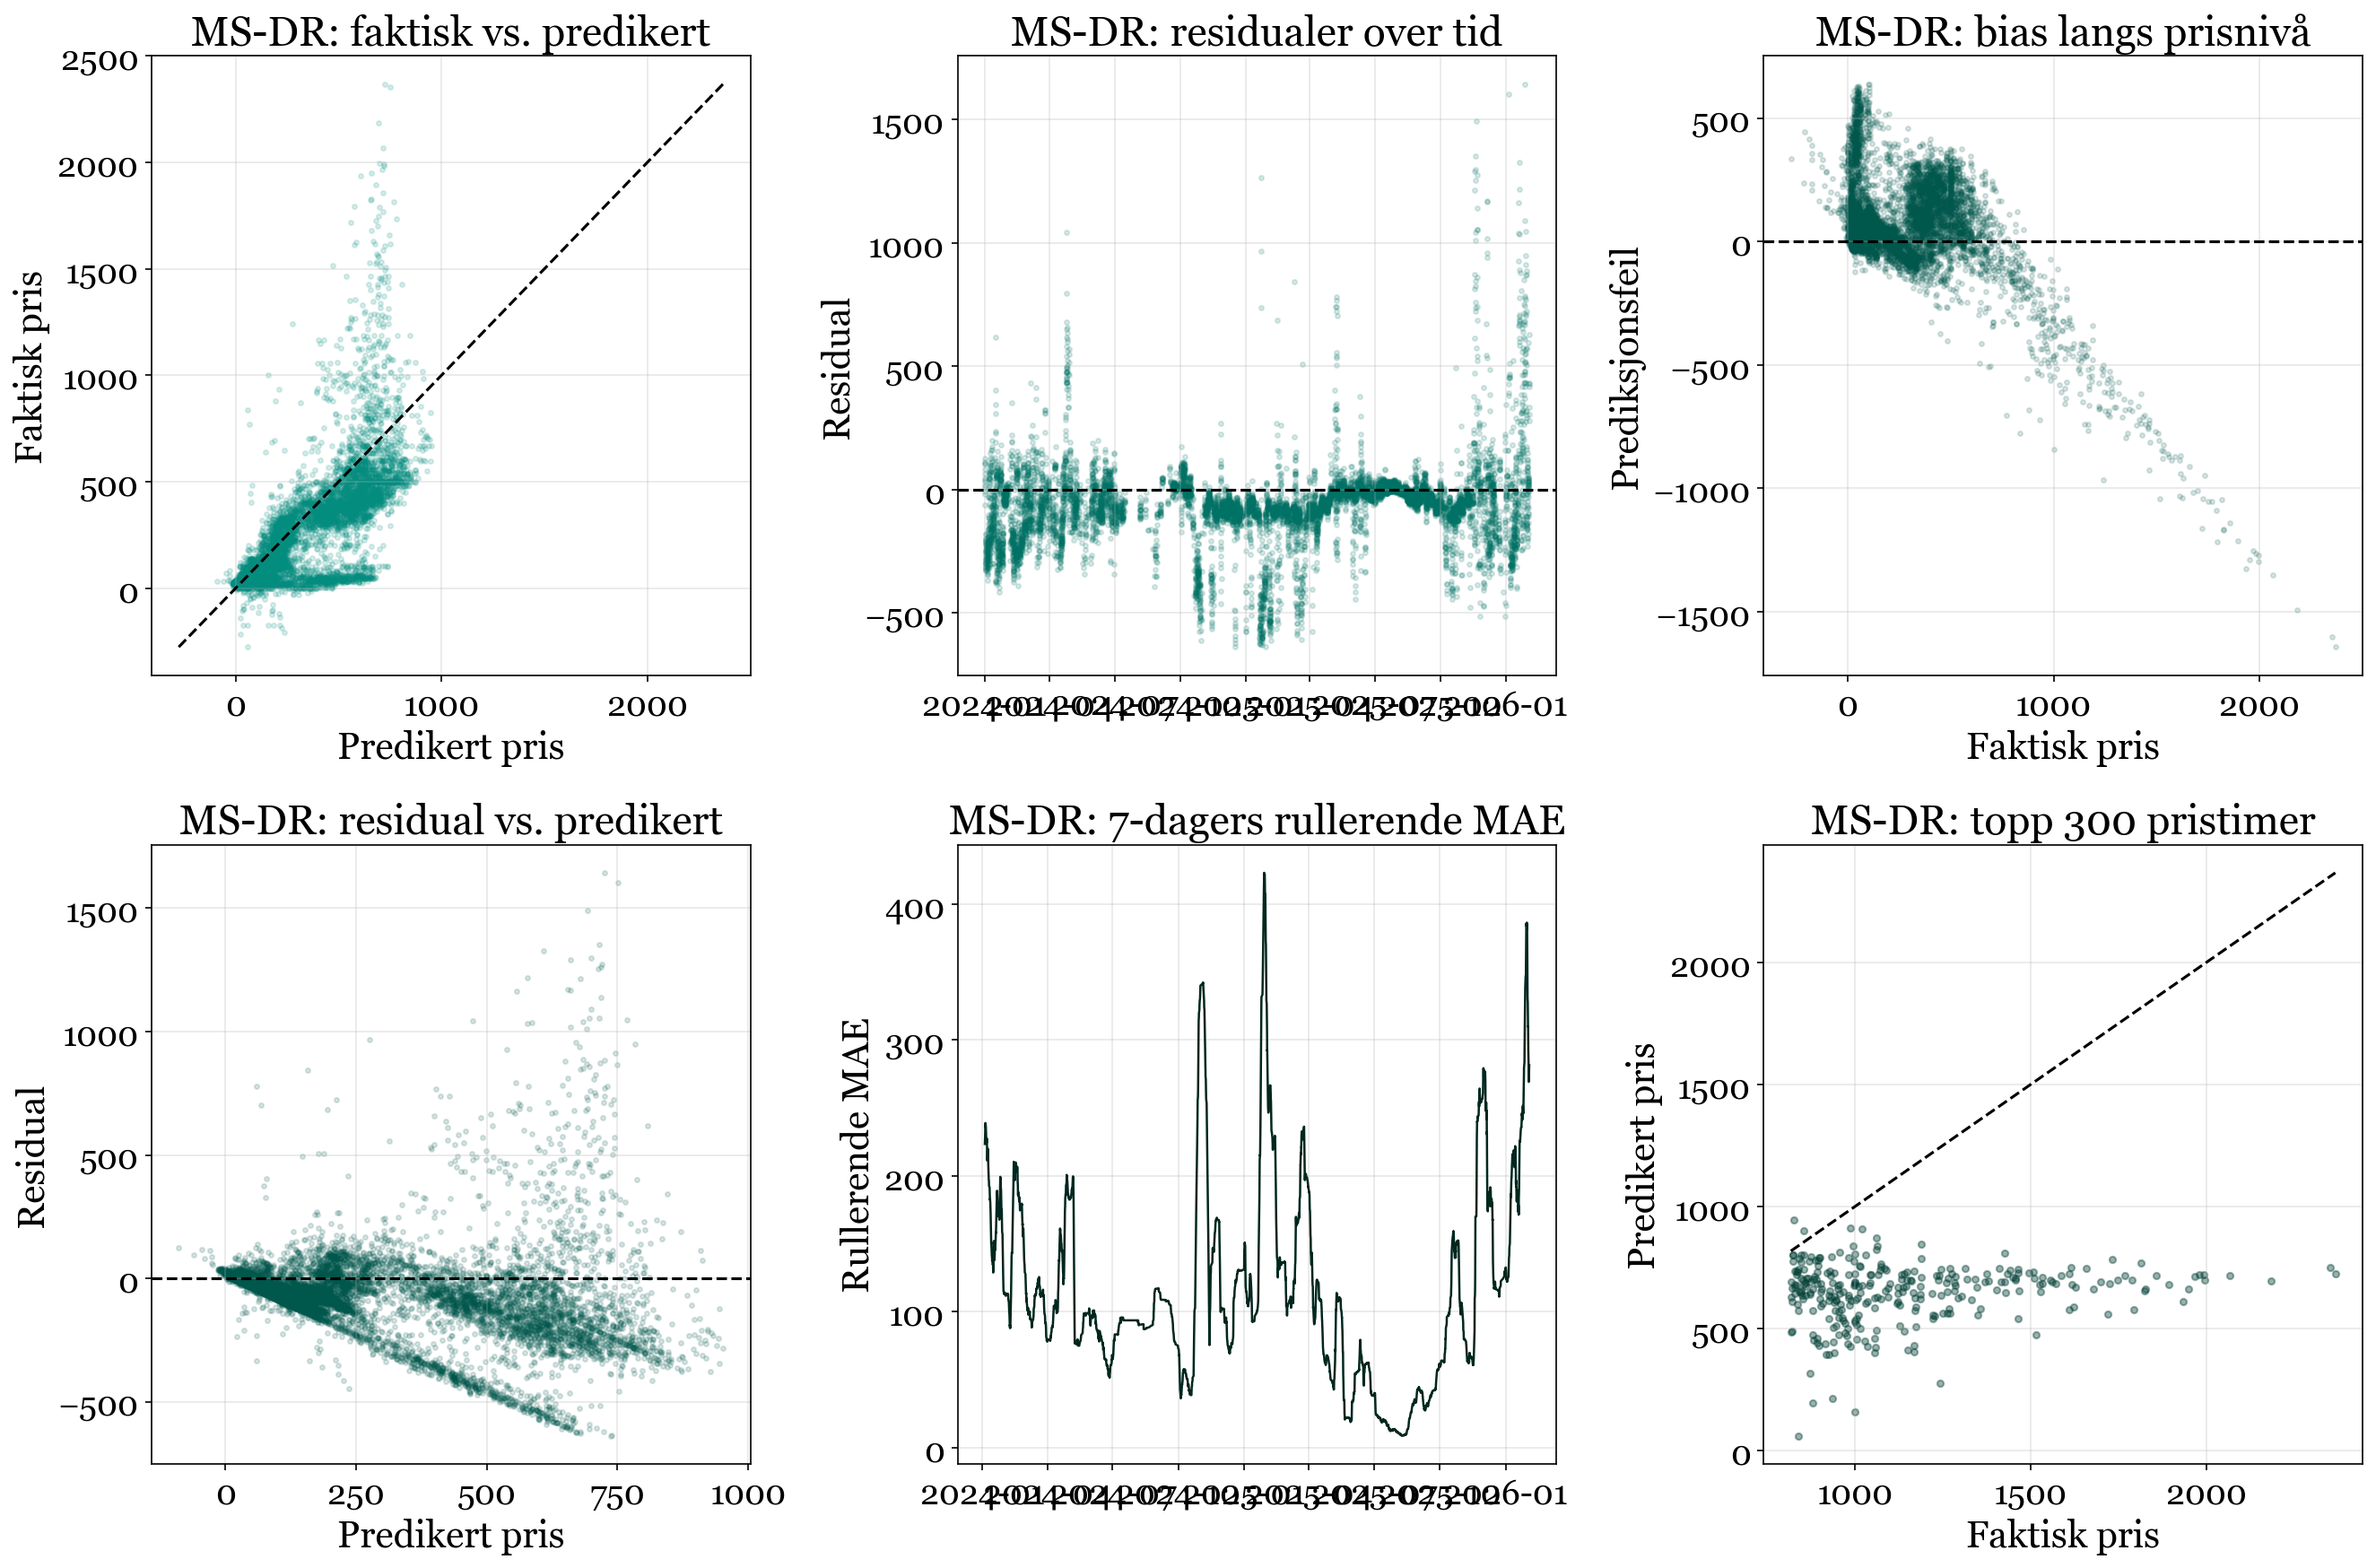

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

line_min = min(df_preds["actual"].min(), df_preds["MSDR"].min())
line_max = max(df_preds["actual"].max(), df_preds["MSDR"].max())

axes[0, 0].scatter(df_preds["MSDR"], df_preds["actual"], s=6, alpha=0.15, color=C1)
axes[0, 0].plot([line_min, line_max], [line_min, line_max], color="black", ls="--")
axes[0, 0].set_xlabel("Predikert pris")
axes[0, 0].set_ylabel("Faktisk pris")
axes[0, 0].set_title("MS-DR: faktisk vs. predikert")

axes[0, 1].scatter(df_preds.index, df_preds["resid_MSDR"], s=6, alpha=0.15, color=C2)
axes[0, 1].axhline(0, color="black", ls="--")
axes[0, 1].set_ylabel("Residual")
axes[0, 1].set_title("MS-DR: residualer over tid")

axes[0, 2].scatter(df_preds["actual"], df_preds["MSDR"] - df_preds["actual"], s=6, alpha=0.15, color=C3)
axes[0, 2].axhline(0, color="black", ls="--")
axes[0, 2].set_xlabel("Faktisk pris")
axes[0, 2].set_ylabel("Prediksjonsfeil")
axes[0, 2].set_title("MS-DR: bias langs prisnivå")

axes[1, 0].scatter(df_preds["MSDR"], df_preds["resid_MSDR"], s=6, alpha=0.15, color=C3)
axes[1, 0].axhline(0, color="black", ls="--")
axes[1, 0].set_xlabel("Predikert pris")
axes[1, 0].set_ylabel("Residual")
axes[1, 0].set_title("MS-DR: residual vs. predikert")

axes[1, 1].plot(df_preds.index, df_preds["roll_mae_MSDR"], color=C5, lw=1.2)
axes[1, 1].set_ylabel("Rullerende MAE")
axes[1, 1].set_title("MS-DR: 7-dagers rullerende MAE")

msdr_top = df_preds.nlargest(300, "actual")
axes[1, 2].scatter(msdr_top["actual"], msdr_top["MSDR"], s=12, alpha=0.4, color=C4)
axes[1, 2].plot([msdr_top["actual"].min(), msdr_top["actual"].max()],
                [msdr_top["actual"].min(), msdr_top["actual"].max()], color="black", ls="--")
axes[1, 2].set_xlabel("Faktisk pris")
axes[1, 2].set_ylabel("Predikert pris")
axes[1, 2].set_title("MS-DR: topp 300 pristimer")

plt.tight_layout()
plt.savefig(f"{SEC07_DIR}msdr_validation.pdf", bbox_inches="tight")
plt.show()


In [26]:
print("MS-DR — kort tolkning:")
print("- Valideres som regimebasert alternativ til OLS.")
print("- Bias- og tail-plottene viser om modellen håndterer pristopper og nivåskift bedre enn OLS.")
print("- Rullerende MAE brukes for å vurdere stabilitet gjennom testperioden.")


MS-DR — kort tolkning:
- Valideres som regimebasert alternativ til OLS.
- Bias- og tail-plottene viser om modellen håndterer pristopper og nivåskift bedre enn OLS.
- Rullerende MAE brukes for å vurdere stabilitet gjennom testperioden.


## 4.6 Oppsummering

Til slutt lagres en samlet prediksjonstabell og valideringstabeller som kan brukes direkte videre i notebook 5 og 6.


In [27]:
rank_mae = metrics_total[["Modell", "MAE", "RMSE", "R²"]].copy()
rank_mae["Rang (MAE)"] = rank_mae["MAE"].rank(method="dense")
print("Endelig rangeringsoversikt:")
display(rank_mae.sort_values("Rang (MAE)").reset_index(drop=True))

metrics_total.to_parquet(f"{INTERMEDIATE_DIR}validation_metrics_total.parquet")
metrics_year.to_parquet(f"{INTERMEDIATE_DIR}validation_metrics_year.parquet")
metrics_season.to_parquet(f"{INTERMEDIATE_DIR}validation_metrics_season.parquet")
bias_total.to_parquet(f"{INTERMEDIATE_DIR}validation_bias.parquet")
tail_total.to_parquet(f"{INTERMEDIATE_DIR}validation_tail.parquet")
price_level_metrics.to_parquet(f"{INTERMEDIATE_DIR}validation_price_levels.parquet")
df_preds.to_parquet(f"{INTERMEDIATE_DIR}predictions.parquet")

print("Lagret:")
print(f"  {INTERMEDIATE_DIR}validation_metrics_total.parquet")
print(f"  {INTERMEDIATE_DIR}validation_metrics_year.parquet")
print(f"  {INTERMEDIATE_DIR}validation_metrics_season.parquet")
print(f"  {INTERMEDIATE_DIR}validation_bias.parquet")
print(f"  {INTERMEDIATE_DIR}validation_tail.parquet")
print(f"  {INTERMEDIATE_DIR}validation_price_levels.parquet")
print(f"  {INTERMEDIATE_DIR}predictions.parquet")


Endelig rangeringsoversikt:


,Modell,MAE,RMSE,R²,Rang (MAE)
0,Baseline lag-1,26.7,77.5,0.9083,1.0
1,Baseline lag-24,93.2,197.0,0.4075,2.0
2,MS-DR (2 reg.),118.3,183.6,0.4856,3.0
3,QuantReg Q50,125.4,207.5,0.3429,4.0
4,OLS (HAC),154.6,222.8,0.2425,5.0
5,XGBoost,180.7,264.5,-0.0679,6.0
6,2SLS (HAC),188.6,251.6,0.0340,7.0
7,QuantReg Q90,293.0,360.5,-0.9837,8.0


Lagret:
  intermediate/validation_metrics_total.parquet
  intermediate/validation_metrics_year.parquet
  intermediate/validation_metrics_season.parquet
  intermediate/validation_bias.parquet
  intermediate/validation_tail.parquet
  intermediate/validation_price_levels.parquet
  intermediate/predictions.parquet
